In [1]:
% UJILE UNYE DAVID 3065365 18/03/2026
% Waste Management Classification using Multi Model Transfer Learning
% Models Trained: AlexNet, ResNet-101, MobileNetV2, EfficientNet-B0, GoogLeNet
% Metrics & Plots Derived: Accuracy, Precision, Recall, F1, AUC-ROC, Confusion Matrix

In [2]:
close all;
clear;
clc;


**LOADING DATASET**


In [3]:
unzip('GarbageDataset.zip'); %unzipping dataset
imds = imageDatastore('GarbageDataset', ...
'IncludeSubfolders',true, ...
'LabelSource','foldernames'); % access dataset subfolders and assign content to imds variable setting folder names as classes

In [4]:
numbObs = length(imds.Labels) % displaying total length of all labels in dataset

numbObs = 8902



**DISPLAY TOTAL NUMBER OF LABELS & FREQUENCY COUNT OF EACH LABEL**


In [5]:
labelCount = countEachLabel(imds) %display total counbt of existig labels


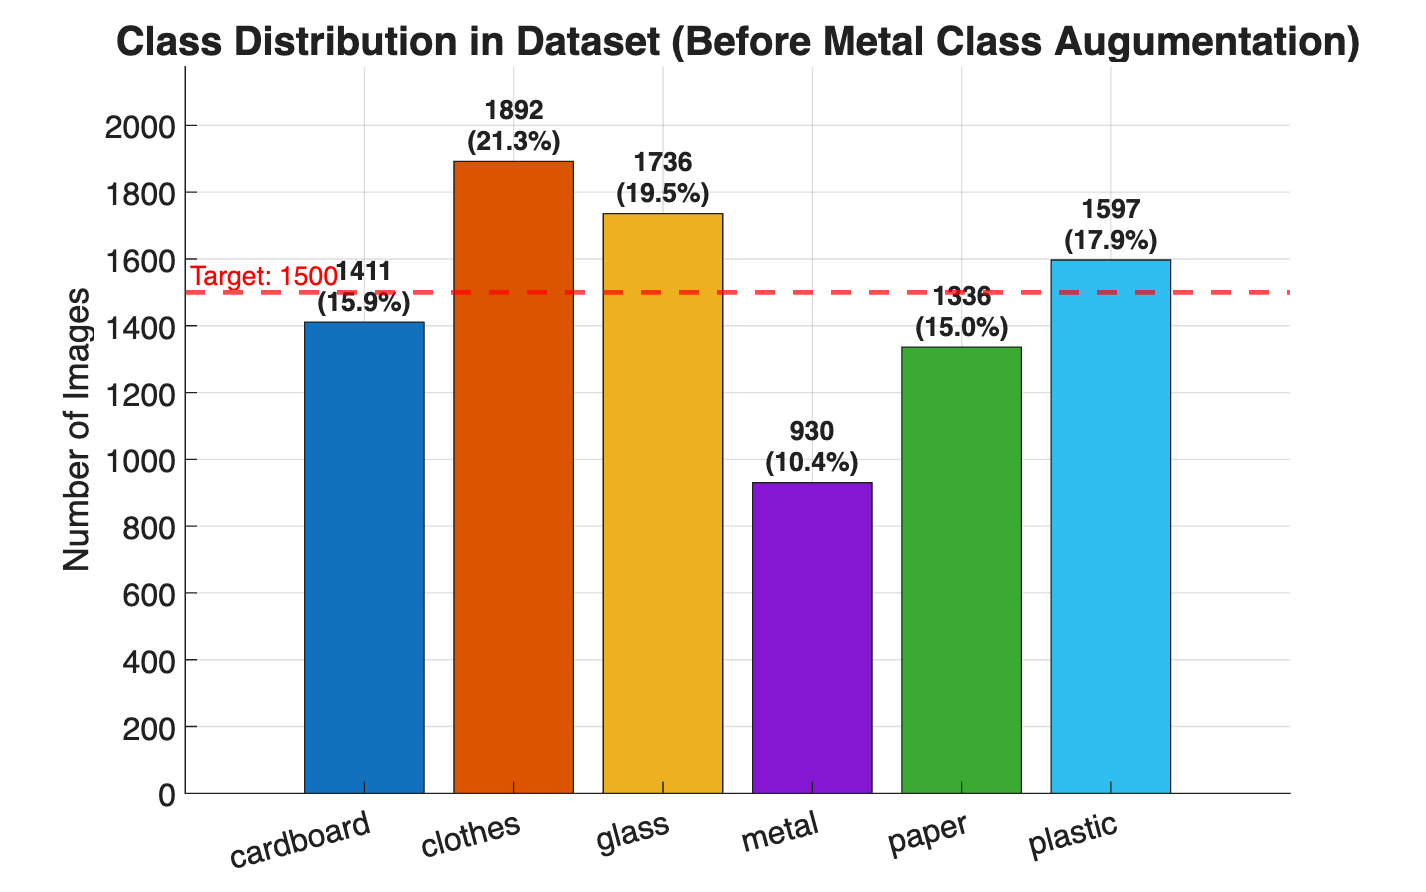

In [6]:
figure('Name','Class Distribution','NumberTitle','off', ...
       'Position',[100 100 800 500]);

% Bar chart
b = bar(labelCount.Count, 'FaceColor','flat');

% Assign unique colour per class
palette = lines(height(labelCount));
for i = 1:height(labelCount)
    b.CData(i,:) = palette(i,:);
end

% X axis labels = class names
set(gca, ...
    'XTick',              1:height(labelCount), ...
    'XTickLabel',         cellstr(labelCount.Label), ...
    'XTickLabelRotation', 15, ...
    'FontSize',           12);

ylabel('Number of Images', 'FontSize', 13);
title('Class Distribution in Dataset (Before Metal Class Augumentation)', 'FontSize', 15, 'FontWeight', 'bold');
grid on; box off;

% Annotate count + percentage on top of each bar
total = sum(labelCount.Count);
for i = 1:height(labelCount)
    count = labelCount.Count(i);
    pct   = 100 * count / total;
    text(i, count + max(labelCount.Count)*0.01, ...
         sprintf('%d\n(%.1f%%)', count, pct), ...
         'HorizontalAlignment', 'center', ...
         'VerticalAlignment',   'bottom', ...
         'FontSize',            10, ...
         'FontWeight',          'bold');
end

% Add target line at 1500
yline(1500, 'r--', 'LineWidth', 1.8, ...
      'Label', 'Target: 1500', ...
      'LabelHorizontalAlignment', 'left', ...
      'FontSize', 10);

ylim([0, max(labelCount.Count) * 1.15]);


**METAL CLASS IS TOO LOW SO WE APPLY AUGUMENTATION TO METAL CLASS TO BOOST FROM 900 \-> 1500**


In [7]:
% Step 1: Delete the rogue metals_aug folder if it exists
rogueDir = fullfile('GarbageDataset', 'metals_aug');
if exist(rogueDir, 'dir')
    rmdir(rogueDir, 's');   % 's' = recursive delete
    fprintf('Deleted rogue folder: metals_aug\n');
end

% Step 2: Reload clean datastore (no metals_aug class anymore)
imds = imageDatastore('GarbageDataset', ...
    'IncludeSubfolders', true, ...
    'LabelSource',       'foldernames');

fprintf('Clean label counts:\n');

Clean label counts:

In [8]:
countEachLabel(imds)

In [9]:

% extract the metal label
targetCount  = 1500;
metalLabel   = categorical({'metal'});
metalFiles   = imds.Files(strcmp(cellstr(imds.Labels), 'metal'));
currentCount = numel(metalFiles);
needed       = max(0, targetCount - currentCount);

fprintf('Boosting "metal": %d → %d (%d synthetic needed)\n', ...
    currentCount, targetCount, needed);

Boosting "metal": 930 → 1500 (570 synthetic needed)

In [10]:

%Save augmented images into the prexisitng metal folder
augOutDir = fullfile('GarbageDataset', 'metal');  % same folder as originals

if needed > 0
    idxPool = mod(0:needed-1, numel(metalFiles)) + 1;
    for k = 1:needed
        img = imread(metalFiles{idxPool(k)});
        img = imresize(img, [224 224]);

        % Manual augmentation of images
        if rand > 0.5,  img = fliplr(img);  end
        if rand > 0.5,  img = flipud(img);  end
        angle = (rand * 60) - 30;
        img   = imrotate(img, angle, 'crop');
        img   = imresize(img, [224 224]);   % restore after rotate crop

        % naming augumented images with 'syn_' prefix to distinguish from originals
        imwrite(img, fullfile(augOutDir, sprintf('syn_%05d.jpg', k)));
    end
    fprintf('Augmentation done. Saved %d images to: %s\n', needed, augOutDir);
end

Augmentation done. Saved 570 images to: GarbageDataset/metal

In [11]:

% Reload and verify boost operation
imds = imageDatastore('GarbageDataset', ...
    'IncludeSubfolders', true, ...
    'LabelSource',       'foldernames');

fprintf('\nFinal label counts:\n');

Final label counts:

In [12]:
countEachLabel(imds)


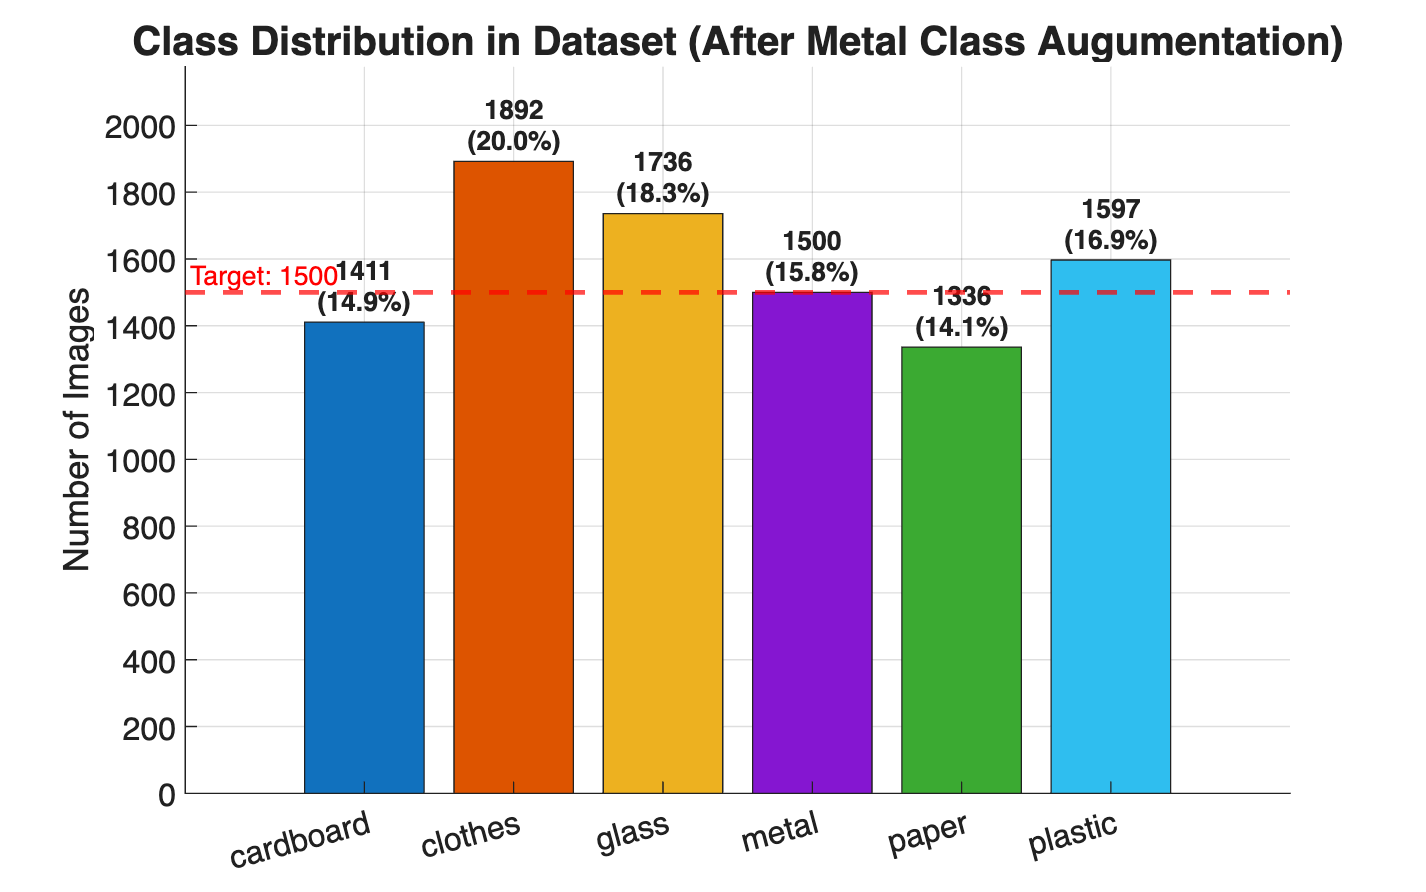

In [13]:
%% CLASS DISTRIBUTION PLOT AFTER METAL CLASS AUGUMENTATION
labelCount = countEachLabel(imds);

figure('Name','Class Distribution','NumberTitle','off', ...
       'Position',[100 100 800 500]);

% Bar chart
b = bar(labelCount.Count, 'FaceColor','flat');

% Assign unique colour per class
palette = lines(height(labelCount));
for i = 1:height(labelCount)
    b.CData(i,:) = palette(i,:);
end

% X axis labels = class names
set(gca, ...
    'XTick',              1:height(labelCount), ...
    'XTickLabel',         cellstr(labelCount.Label), ...
    'XTickLabelRotation', 15, ...
    'FontSize',           12);

ylabel('Number of Images', 'FontSize', 13);
title('Class Distribution in Dataset (After Metal Class Augumentation)', 'FontSize', 15, 'FontWeight', 'bold');
grid on; box off;

% Annotate count + percentage on top of each bar
total = sum(labelCount.Count);
for i = 1:height(labelCount)
    count = labelCount.Count(i);
    pct   = 100 * count / total;
    text(i, count + max(labelCount.Count)*0.01, ...
         sprintf('%d\n(%.1f%%)', count, pct), ...
         'HorizontalAlignment', 'center', ...
         'VerticalAlignment',   'bottom', ...
         'FontSize',            10, ...
         'FontWeight',          'bold');
end

% Add target line at 1500
yline(1500, 'r--', 'LineWidth', 1.8, ...
      'Label', 'Target: 1500', ...
      'LabelHorizontalAlignment', 'left', ...
      'FontSize', 10);

ylim([0, max(labelCount.Count) * 1.15]);

In [14]:
imds.ReadFcn = @(filename) imresize(imread(filename), [224 224]); %resize images to match 224x224x3 for training models


**READ IMAGE SIZE**


In [15]:
img = readimage(imds,3);  %read the third image of the image dataset (imds)
size(img) %output the size of the img variable

ans = 1x3
   224   224     3



**SPLIT TRAINING AND VALIDATION**


In [16]:
% Split off 15% as held-out test set first
[imdsTrain_val, imdsTest] = splitEachLabel(imds, 0.85, 'randomized');

% Split remaining 85% into 70% train / 15% val
% 70/85 = 0.8235 of the train_val portion gives ~70% of total
[imdsTrain, imdsValidation] = splitEachLabel(imdsTrain_val, 0.8235, 'randomized');

% Verify proportions
total = numel(imds.Files);
fprintf('Total    : %d (100%%)\n', total);

Total    : 9472 (100%)

In [17]:
fprintf('\nClass distribution in training set:\n');

Class distribution in training set:

In [18]:
countEachLabel(imdsTrain)


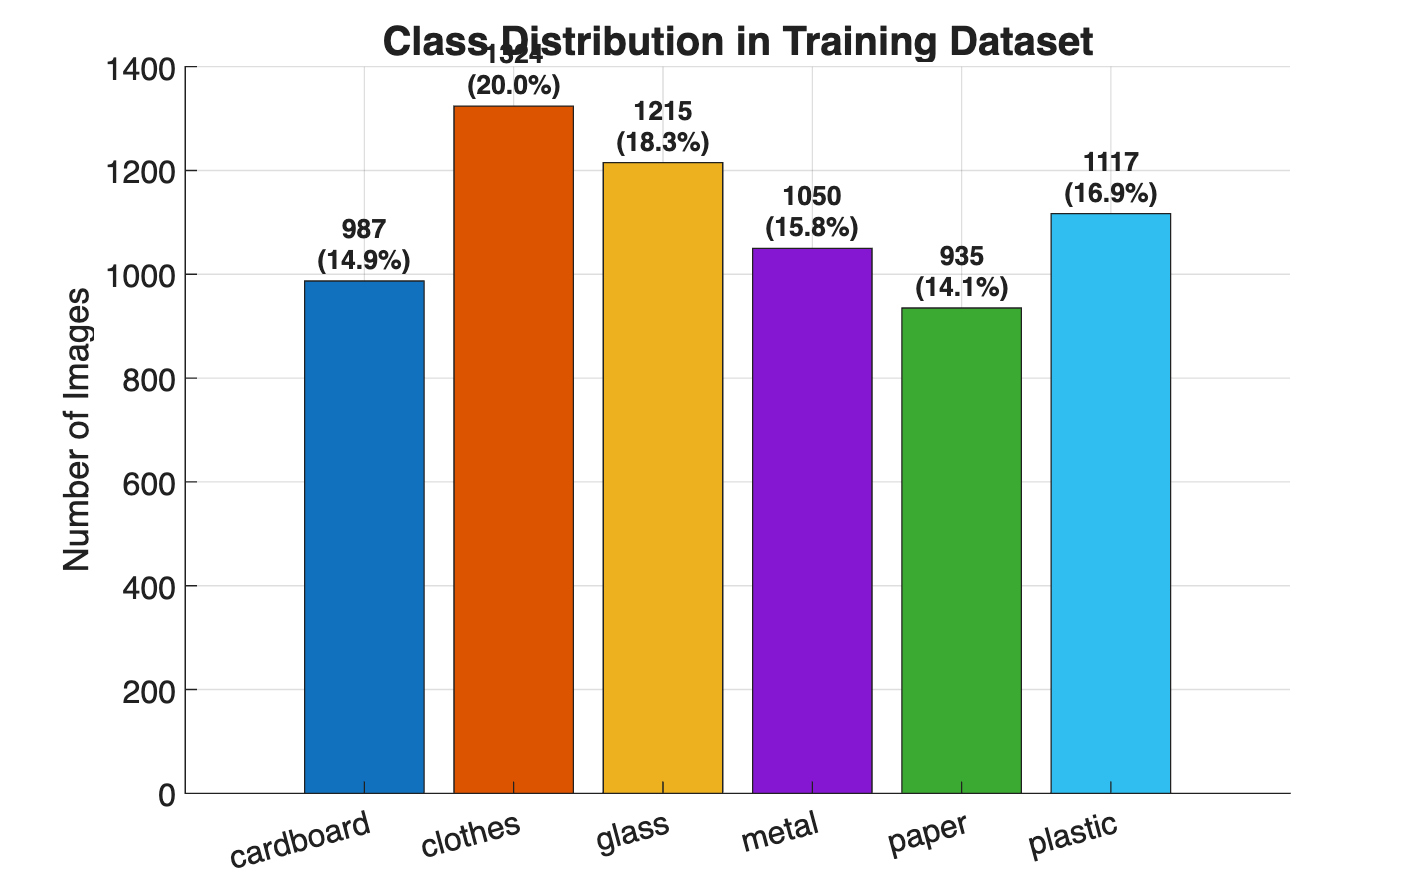

In [19]:
%% CLASS DISTRIBUTION PLOT IN TRAINING SET
labelCount = countEachLabel(imdsTrain);

figure('Name','Class Distribution','NumberTitle','off', ...
       'Position',[100 100 800 500]);

% Bar chart
b = bar(labelCount.Count, 'FaceColor','flat');

% Assign unique colour per class
palette = lines(height(labelCount));
for i = 1:height(labelCount)
    b.CData(i,:) = palette(i,:);
end

% X axis labels = class names
set(gca, ...
    'XTick',              1:height(labelCount), ...
    'XTickLabel',         cellstr(labelCount.Label), ...
    'XTickLabelRotation', 15, ...
    'FontSize',           12);

ylabel('Number of Images', 'FontSize', 13);
title('Class Distribution in Training Dataset', 'FontSize', 15, 'FontWeight', 'bold');
grid on; box off;

% Annotate count + percentage on top of each bar
total = sum(labelCount.Count);
for i = 1:height(labelCount)
    count = labelCount.Count(i);
    pct   = 100 * count / total;
    text(i, count + max(labelCount.Count)*0.01, ...
         sprintf('%d\n(%.1f%%)', count, pct), ...
         'HorizontalAlignment', 'center', ...
         'VerticalAlignment',   'bottom', ...
         'FontSize',            10, ...
         'FontWeight',          'bold');
end


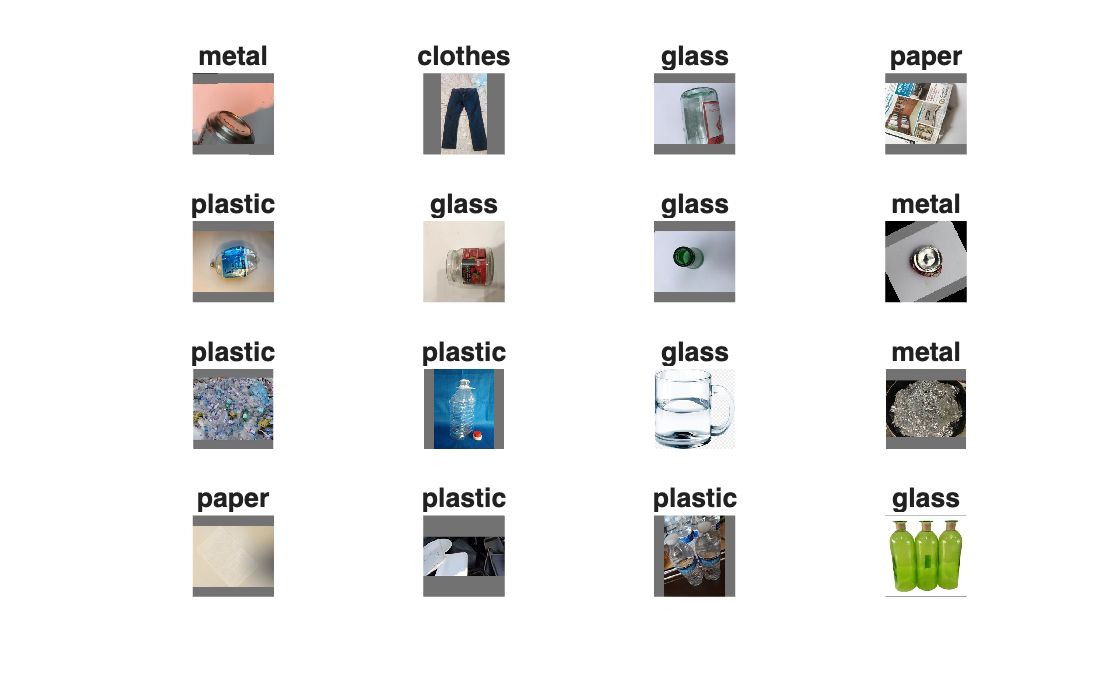

In [20]:
numTrainImages = numel(imdsTrain.Labels);
numClasses = numel(categories(imdsTrain.Labels));
classNames = categories(imdsTrain.Labels);
idx = randperm(numTrainImages,16);
figure
for i = 1:16
    subplot(4,4,i)
    I = readimage(imdsTrain, idx(i));
    imshow(I)
    axis off
    lbl = imdsTrain.Labels(idx(i));         % categorical or string
    title(string(lbl), 'Interpreter', 'none', 'FontSize', 10)
end


**LOADING & REGISTERING MODELS ACCORDING TO THEIR REQUIRED IMAGE SIZES**


In [21]:
modelList = {
    'AlexNet',        @alexnet,        [227 227 3], 3;
    'ResNet-101',     @resnet101,      [224 224 3], 2;
    'MobileNet-V2',   @mobilenetv2,    [224 224 3], 3;
    'EfficientNet-B0',@efficientnetb0, [224 224 3], 3;
    'GoogLeNet',      @googlenet,      [224 224 3], 3;
};

numModels = size(modelList, 1);

% Storage for all results
allMetrics = struct();
allYPred   = cell(numModels, 1);
allScores  = cell(numModels, 1);
YTrue      = [];   % filled on first pass


**IMPLEMENTING TRAINING PIPELINE & LOOP FOR MUTLI MODELS TO AVOID EXCESSIVE CODE REPITION**


Currently Training: AlexNet
Training on single CPU.
Initializing input data normalization.
|======================================================================================================================|
|  Epoch  |  Iteration  |  Time Elapsed  |  Mini-batch  |  Validation  |  Mini-batch  |  Validation  |  Base Learning  |
|         |             |   (hh:mm:ss)   |   Accuracy   |   Accuracy   |     Loss     |     Loss     |      Rate       |
|======================================================================================================================|
|       1 |           1 |       00:00:14 |       21.88% |       17.29% |       3.8879 |       2.5282 |      1.0000e-04 |
|       1 |          10 |       00:00:36 |       46.88% |       63.81% |       1.7549 |       1.1320 |      1.0000e-04 |
|       1 |          20 |       00:00:54 |       78.12% |       71.89% |       0.9391 |       1.0276 |      1.0000e-04 |
|       1 |          30 |       00:01:13 |       71.88% |     


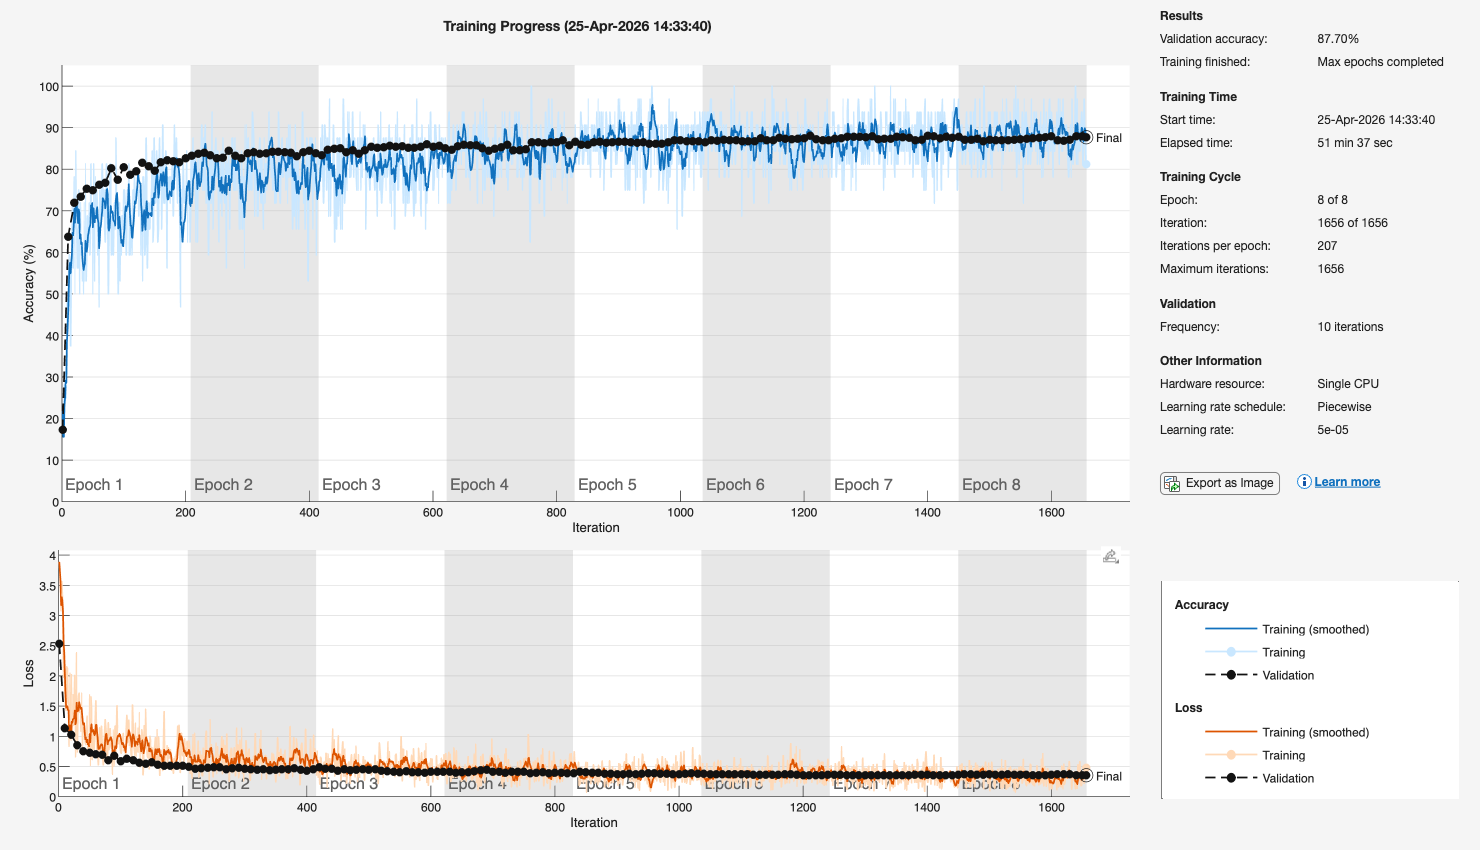

[AlexNet] Acc=87.70%  Prec=87.46%  Rec=87.34%  F1=87.39%  AUC=0.9864
[AlexNet] Checkpoint saved.
Currently Training: ResNet-101
  Replacing layers: fc1000 | prob | ClassificationLayer_predictions
Training on single CPU.
Initializing input data normalization.
|======================================================================================================================|
|  Epoch  |  Iteration  |  Time Elapsed  |  Mini-batch  |  Validation  |  Mini-batch  |  Validation  |  Base Learning  |
|         |             |   (hh:mm:ss)   |   Accuracy   |   Accuracy   |     Loss     |     Loss     |      Rate       |
|======================================================================================================================|
|       1 |           1 |       00:01:42 |       28.12% |       19.54% |       2.0329 |       2.2377 |      1.0000e-04 |
|       1 |          10 |       00:04:39 |       25.00% |       45.05% |       1.6483 |       1.4640 |      1.0000e-04 |
|       1 |    


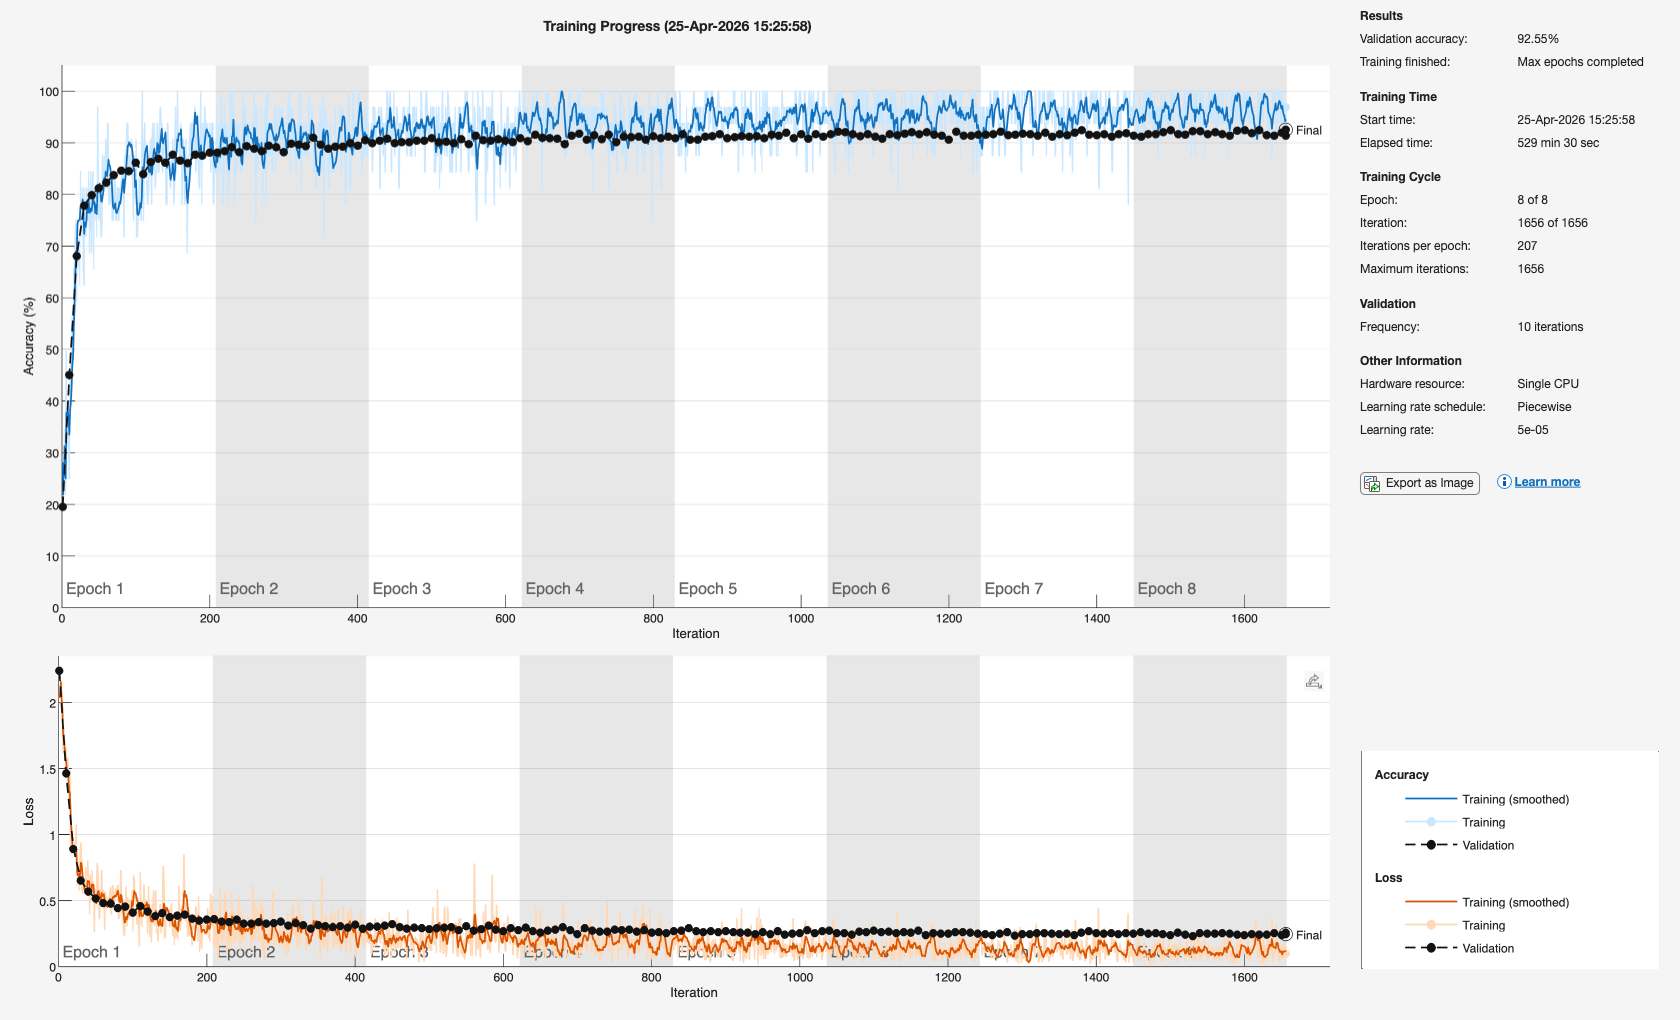

[ResNet-101] Acc=92.55%  Prec=92.42%  Rec=92.36%  F1=92.32%  AUC=0.9932
[ResNet-101] Checkpoint saved.
Currently Training: MobileNet-V2
  Replacing layers: Logits | Logits_softmax | ClassificationLayer_Logits
Training on single CPU.
Initializing input data normalization.
|======================================================================================================================|
|  Epoch  |  Iteration  |  Time Elapsed  |  Mini-batch  |  Validation  |  Mini-batch  |  Validation  |  Base Learning  |
|         |             |   (hh:mm:ss)   |   Accuracy   |   Accuracy   |     Loss     |     Loss     |      Rate       |
|======================================================================================================================|
|       1 |           1 |       00:00:36 |       21.88% |       14.90% |       1.9600 |       2.0965 |      1.0000e-04 |
|       1 |          10 |       00:01:40 |       28.12% |       24.67% |       1.7070 |       1.8143 |      1.0000e-04 |
| 


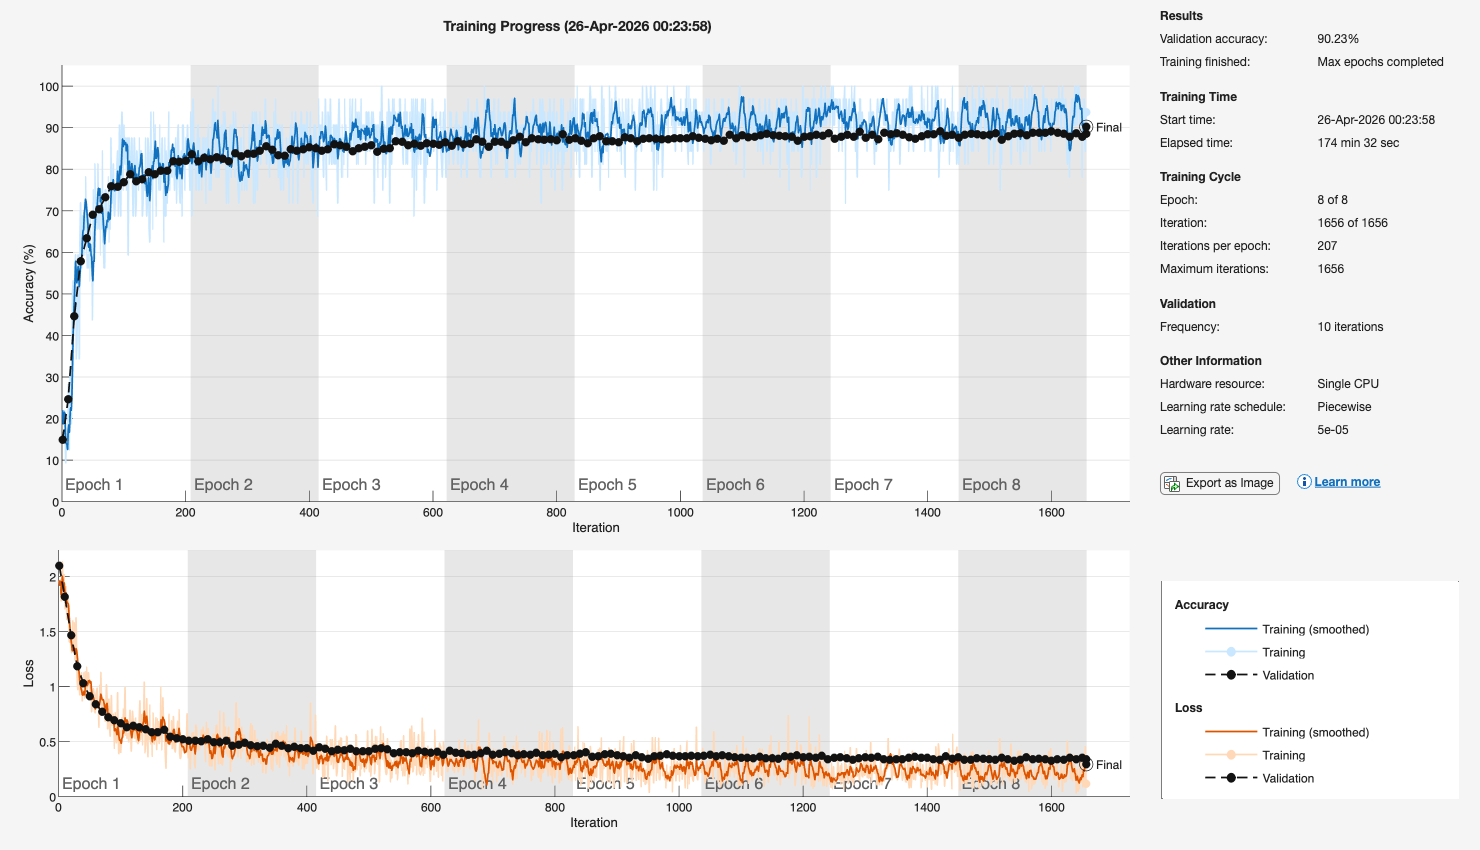

[MobileNet-V2] Acc=90.23%  Prec=90.08%  Rec=89.95%  F1=89.89%  AUC=0.9890
[MobileNet-V2] Checkpoint saved.
Currently Training: EfficientNet-B0
  Replacing layers: efficientnet-b0|model|head|dense|MatMul | Softmax | classification
Training on single CPU.
Initializing input data normalization.
|======================================================================================================================|
|  Epoch  |  Iteration  |  Time Elapsed  |  Mini-batch  |  Validation  |  Mini-batch  |  Validation  |  Base Learning  |
|         |             |   (hh:mm:ss)   |   Accuracy   |   Accuracy   |     Loss     |     Loss     |      Rate       |
|======================================================================================================================|
|       1 |           1 |       00:00:57 |        6.25% |       17.22% |       1.8470 |       1.8414 |      1.0000e-04 |
|       1 |          10 |       00:02:46 |       12.50% |       25.02% |       1.9121 |       1.7527 |


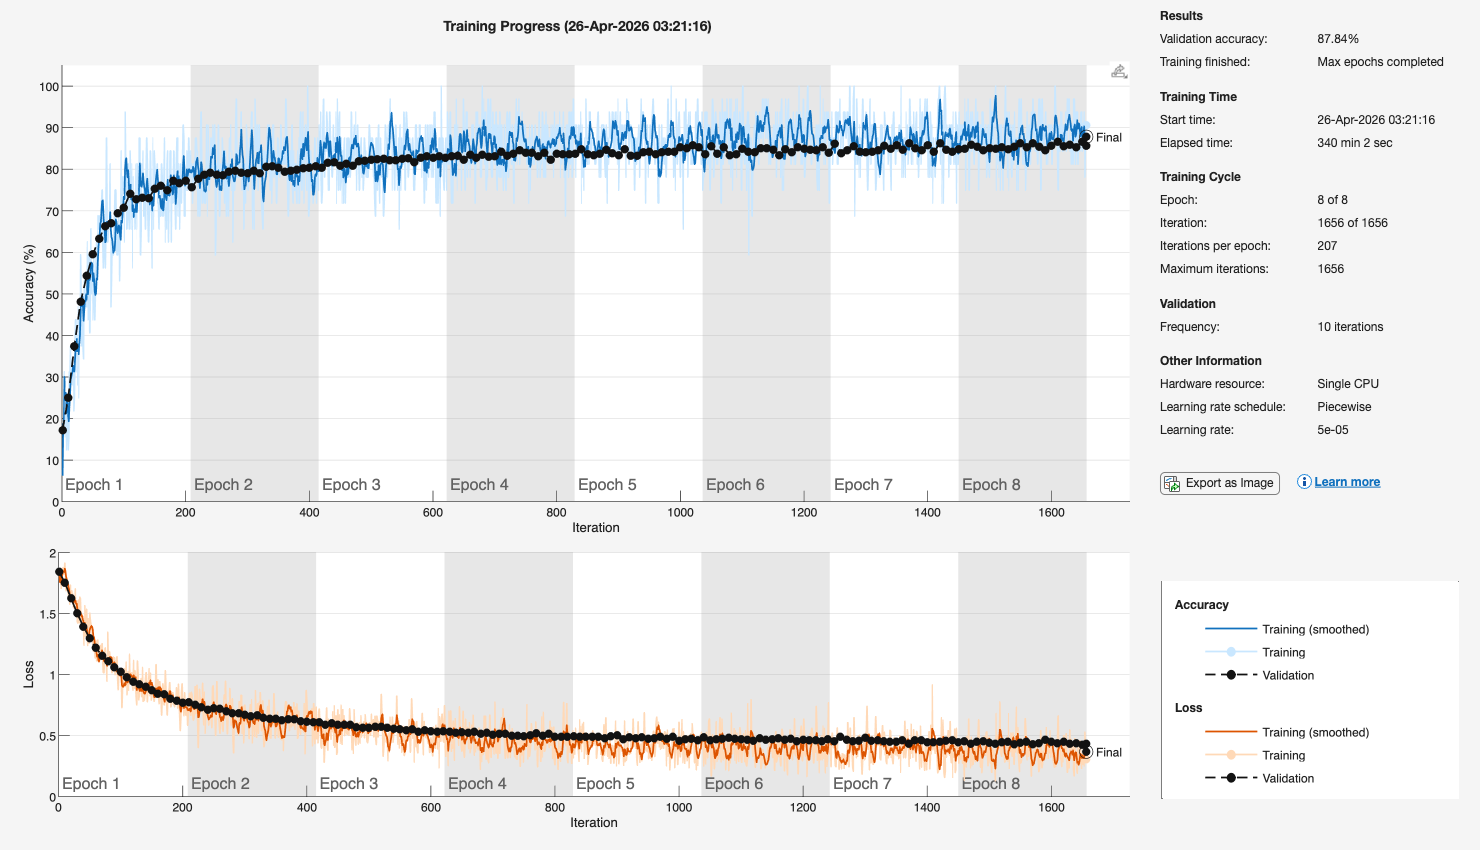

[EfficientNet-B0] Acc=87.84%  Prec=87.72%  Rec=87.51%  F1=87.44%  AUC=0.9854
[EfficientNet-B0] Checkpoint saved.
Currently Training: GoogLeNet
  Replacing layers: loss3-classifier | prob | output
Training on single CPU.
Initializing input data normalization.
|======================================================================================================================|
|  Epoch  |  Iteration  |  Time Elapsed  |  Mini-batch  |  Validation  |  Mini-batch  |  Validation  |  Base Learning  |
|         |             |   (hh:mm:ss)   |   Accuracy   |   Accuracy   |     Loss     |     Loss     |      Rate       |
|======================================================================================================================|
|       1 |           1 |       00:00:26 |       15.62% |       11.67% |       3.0687 |       2.9244 |      1.0000e-04 |
|       1 |          10 |       00:01:10 |       43.75% |       49.26% |       1.6073 |       1.5004 |      1.0000e-04 |
|       1 |    


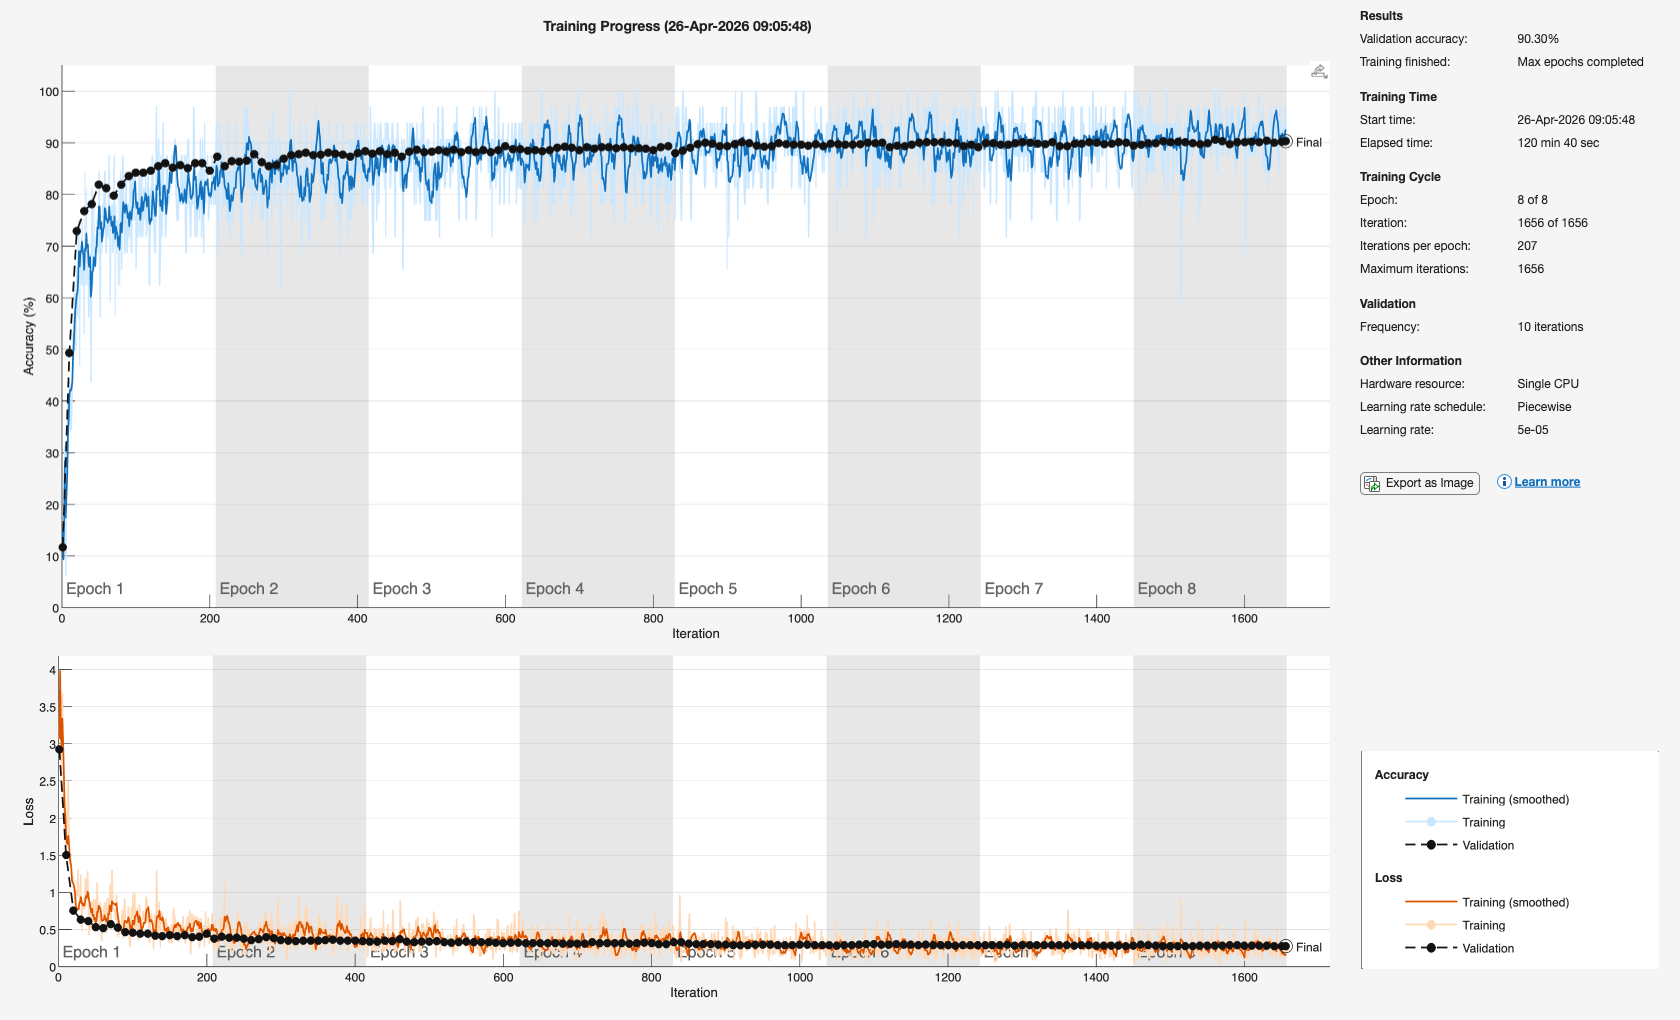

[GoogLeNet] Acc=90.30%  Prec=90.08%  Rec=89.96%  F1=89.96%  AUC=0.9908
[GoogLeNet] Checkpoint saved.

In [22]:
for m = 1:numModels
    modelName = modelList{m,1};
    loaderFn  = modelList{m,2};
    inputSz   = modelList{m,3};
    dropLast  = modelList{m,4};


    fprintf('Currently Training: %s\n', modelName);


    % Load pretrained network (handle networks with different APIs)
    try
        net = loaderFn();
    catch ME
        warning('Could not load %s: %s — skipping.', modelName, ME.message);
        continue;
    end

    % Transfer: strip last N classification layers
    layersTransfer = net.Layers(1:end-dropLast);

    % Append new head
    newLayers = [
        layersTransfer
        fullyConnectedLayer(numClasses, ...
            'WeightLearnRateFactor', 20, ...
            'BiasLearnRateFactor',   20)
        softmaxLayer
        classificationLayer
    ];

    % Data augmentation for training
    pixelRange = [-30 30];
    augmenter  = imageDataAugmenter( ...
        'RandXReflection',  true, ...
        'RandXTranslation', pixelRange, ...
        'RandYTranslation', pixelRange, ...
        'RandRotation',     [-15 15]);

 imdsTrain.ReadFcn      = @(filename) imread(filename);
imdsValidation.ReadFcn = @(filename) imread(filename);

augimdsTrain = augmentedImageDatastore(inputSz(1:2), imdsTrain, ...
    'DataAugmentation', augmenter, 'ColorPreprocessing', 'gray2rgb');
augimdsValidation = augmentedImageDatastore(inputSz(1:2), imdsValidation, ...
    'ColorPreprocessing', 'gray2rgb');

    % Training options
    options = trainingOptions('sgdm', ...
        'MiniBatchSize',       32, ...
        'MaxEpochs',          8, ...
        'InitialLearnRate',    1e-4, ...
        'LearnRateSchedule',   'piecewise', ...
        'LearnRateDropFactor', 0.5, ...
        'LearnRateDropPeriod', 4, ...
        'L2Regularization',    1e-4, ...
        'Momentum',            0.9, ...
        'Shuffle',             'every-epoch', ...
        'ValidationData',      augimdsValidation, ...
        'ValidationFrequency', 10, ...
        'Verbose',             true, ...
        'Plots','training-progress');

    % Train
    % ── BUILD NETWORK (SeriesNetwork vs DAG) ──────────────
    if isa(net, 'SeriesNetwork')
        % AlexNet, GoogLeNet — simple layer slicing
        layersTransfer = net.Layers(1:end-dropLast);
        newLayers = [
            layersTransfer
            fullyConnectedLayer(numClasses, ...
                'WeightLearnRateFactor', 20, ...
                'BiasLearnRateFactor',   20, ...
                'Name', 'new_fc')
            softmaxLayer('Name', 'new_softmax')
            classificationLayer('Name', 'new_classoutput')
        ];
        trainedNet = trainNetwork(augimdsTrain, newLayers, options);

    else
        % ResNet-101, MobileNetV2, EfficientNet — DAG with skip connections
        lgraph = layerGraph(net);
        layers    = lgraph.Layers;
        numLayers = numel(layers);

        % Get existing head layer names to preserve graph connections
        outputLayerName  = layers(numLayers).Name;
        softmaxLayerName = layers(numLayers-1).Name;
        fcLayerName      = layers(numLayers-2).Name;

        fprintf('  Replacing layers: %s | %s | %s\n', ...
            fcLayerName, softmaxLayerName, outputLayerName);

        % Replace with new layers keeping same names
        newFC      = fullyConnectedLayer(numClasses, ...
                         'WeightLearnRateFactor', 20, ...
                         'BiasLearnRateFactor',   20, ...
                         'Name', fcLayerName);
        newSoftmax = softmaxLayer('Name', softmaxLayerName);
        newOutput  = classificationLayer('Name', outputLayerName);

        lgraph = replaceLayer(lgraph, fcLayerName,      newFC);
        lgraph = replaceLayer(lgraph, softmaxLayerName, newSoftmax);
        lgraph = replaceLayer(lgraph, outputLayerName,  newOutput);

        trainedNet = trainNetwork(augimdsTrain, lgraph, options);
    end


    % Predict with scores
    % ── PREDICT
    [YPred, scores] = classify(trainedNet, augimdsValidation);

    % Store ground truth once
    if isempty(YTrue)
        YTrue = imdsValidation.Labels;
    end

    allYPred{m}  = YPred;
    allScores{m} = scores;

    % PER-CLASS METRICS
    C = confusionmat(YTrue, YPred);

    precision = zeros(numClasses, 1);
    recall    = zeros(numClasses, 1);
    f1        = zeros(numClasses, 1);

    for c = 1:numClasses
        TP = C(c,c);
        FP = sum(C(:,c)) - TP;
        FN = sum(C(c,:)) - TP;

        precision(c) = TP / max(TP + FP, 1);
        recall(c)    = TP / max(TP + FN, 1);
        f1(c)        = 2 * precision(c) * recall(c) / ...
                       max(precision(c) + recall(c), eps);
    end

    accuracy = mean(YPred == YTrue);

    % AUC-ROC
    auc = zeros(numClasses, 1);
    for c = 1:numClasses
        % Convert both sides to string for comparison — avoids categorical error
        binaryTrue = double(strcmp(cellstr(YTrue), classNames{c}));
        [~, ~, ~, auc(c)] = perfcurve(binaryTrue, scores(:,c), 1);
    end
    macroAUC = mean(auc);

    % STORE METRICS with percentages (%)
    allMetrics(m).name       = modelName;
    allMetrics(m).accuracy   = accuracy * 100;
    allMetrics(m).precision  = mean(precision) * 100;
    allMetrics(m).recall     = mean(recall)    * 100;
    allMetrics(m).f1         = mean(f1)        * 100;
    allMetrics(m).auc        = macroAUC;
    allMetrics(m).perClassP  = precision * 100;
    allMetrics(m).perClassR  = recall    * 100;
    allMetrics(m).perClassF1 = f1        * 100;
    allMetrics(m).perClassAUC= auc;
    allMetrics(m).confMat    = C;

    fprintf('\n[%s] Acc=%.2f%%  Prec=%.2f%%  Rec=%.2f%%  F1=%.2f%%  AUC=%.4f\n', ...
        modelName, accuracy*100, mean(precision)*100, mean(recall)*100, ...
        mean(f1)*100, macroAUC);

    % ── SAVE CHECKPOINT immediately after metrics ─────────
    checkpointDir = fullfile('GarbageDataset', 'checkpoints');
    if ~exist(checkpointDir, 'dir'), mkdir(checkpointDir); end

    metrics = allMetrics(m);
    save(fullfile(checkpointDir, sprintf('%s_results.mat', ...
         strrep(modelName,' ','_'))), ...
         'metrics', 'YPred', 'scores', 'YTrue');
    fprintf('[%s] Checkpoint saved.\n', modelName);

% Filter out any skipped models
validMask   = arrayfun(@(s) ~isempty(s.name), allMetrics);
allMetrics  = allMetrics(validMask);
numValid    = numel(allMetrics);
modelNames  = {allMetrics.name};
end



**GOOGLENET TEST ACCURACY**


In [23]:
% 1. Prepare the test data for GoogLeNet (Requires 224x224)
% We use 'gray2rgb' to ensure 3-channel input if your images are grayscale
augimdsTest = augmentedImageDatastore([224 224], imdsTest, ...
    'ColorPreprocessing', 'gray2rgb');

% 2. Run classification on the unseen data
fprintf('Computing test accuracy for GoogLeNet...\n')

Computing test accuracy for GoogLeNet...

In [24]:
[YPredTest, scoresTest] = classify(trainedNet, augimdsTest);

% 3. Calculate Accuracy
YTrueTest = imdsTest.Labels;
googlenetTestAcc = mean(YPredTest == YTrueTest) * 100;

% 4. Display Results
fprintf('GoogLeNet Test Accuracy: %.2f%%\n', googlenetTestAcc)

GoogLeNet Test Accuracy: 89.94%


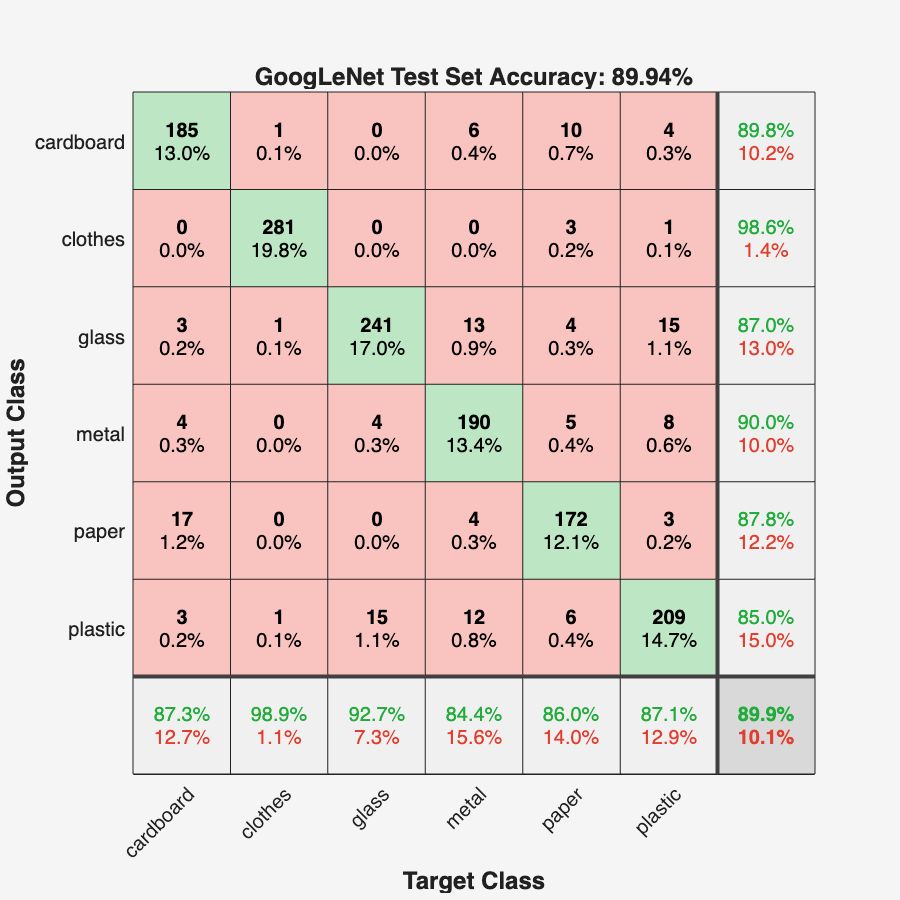

In [25]:

% 5. Optional: Plot a Confusion Matrix for the Test Set
figure('Name', 'GoogLeNet Test Confusion Matrix');
plotconfusion(YTrueTest, YPredTest);
title(['GoogLeNet Test Set Accuracy: ', num2str(googlenetTestAcc, '%.2f'), '%']);


**METRICS & PLOTS**


In [26]:
%FIGURE 1 — COMBINED METRICS COMPARISON (grouped bar chart)
% Accuracy, Precision, Recall, F1, AUC×100 side-by-side

In [27]:
checkpointDir = fullfile('GarbageDataset', 'checkpoints');
modelFiles    = {
    'AlexNet',         'AlexNet_results.mat';
    'ResNet-101',      'ResNet-101_results.mat';
    'MobileNet-V2',    'MobileNet-V2_results.mat';
    'EfficientNet-B0', 'EfficientNet-B0_results.mat';
    'GoogLeNet',       'GoogLeNet_results.mat';
};

% Reload all metrics cleanly from disk
cleanMetrics = [];
cleanNames   = {};
allYPred     = {};
allScores    = {};
YTrue        = [];

for i = 1:size(modelFiles,1)
    fpath = fullfile(checkpointDir, modelFiles{i,2});
    if exist(fpath, 'file')
        loaded = load(fpath);
        cleanMetrics = [cleanMetrics, loaded.metrics];
        cleanNames{end+1} = modelFiles{i,1};
        allYPred{end+1}   = loaded.YPred;
        allScores{end+1}  = loaded.scores;
        if isempty(YTrue)
            YTrue = loaded.YTrue;
        end
        fprintf('[%s] Loaded — Acc=%.2f%%  Prec=%.2f%%  Rec=%.2f%%  F1=%.2f%%  AUC=%.4f\n', ...
            modelFiles{i,1}, ...
            loaded.metrics.accuracy, ...
            loaded.metrics.precision, ...
            loaded.metrics.recall, ...
            loaded.metrics.f1, ...
            loaded.metrics.auc);
    else
        fprintf('[%s] No checkpoint found — skipping.\n', modelFiles{i,1});
    end
end

[AlexNet] Loaded — Acc=87.70%  Prec=87.46%  Rec=87.34%  F1=87.39%  AUC=0.9864
[ResNet-101] Loaded — Acc=92.55%  Prec=92.42%  Rec=92.36%  F1=92.32%  AUC=0.9932
[MobileNet-V2] Loaded — Acc=90.23%  Prec=90.08%  Rec=89.95%  F1=89.89%  AUC=0.9890
[EfficientNet-B0] Loaded — Acc=87.84%  Prec=87.72%  Rec=87.51%  F1=87.44%  AUC=0.9854
[GoogLeNet] Loaded — Acc=90.30%  Prec=90.08%  Rec=89.96%  F1=89.96%  AUC=0.9908

In [28]:

% Use clean data for all plots
allMetrics = cleanMetrics;
numValid   = numel(allMetrics);
modelNames = cleanNames;
classNames = categories(YTrue);
numClasses = numel(classNames);

% Verify values match printed output
fprintf('\n PLOT DATA VERIFICATION \n');

 PLOT DATA VERIFICATION

In [29]:
fprintf('%-18s %8s %10s %8s %8s %8s\n', ...
    'Model','Acc(%)','Prec(%)','Rec(%)','F1(%)','AUC');

Model                Acc(%)    Prec(%)   Rec(%)    F1(%)      AUC

In [30]:
fprintf('%s\n', repmat('-',1,65));

-----------------------------------------------------------------

In [31]:
for i = 1:numValid
    fprintf('%-18s %8.2f %10.2f %8.2f %8.2f %8.4f\n', ...
        modelNames{i}, ...
        allMetrics(i).accuracy, ...
        allMetrics(i).precision, ...
        allMetrics(i).recall, ...
        allMetrics(i).f1, ...
        allMetrics(i).auc);
end

AlexNet               87.70      87.46    87.34    87.39   0.9864
ResNet-101            92.55      92.42    92.36    92.32   0.9932
MobileNet-V2          90.23      90.08    89.95    89.89   0.9890
EfficientNet-B0       87.84      87.72    87.51    87.44   0.9854
GoogLeNet             90.30      90.08    89.96    89.96   0.9908

In [32]:
fprintf('%s\n', repmat('=',1,65));

In [33]:

% Build metric matrix directly — no struct array ambiguity
metricMatrix = zeros(numValid, 5);
for i = 1:numValid
    metricMatrix(i,:) = [ ...
        allMetrics(i).accuracy,   ...
        allMetrics(i).precision,  ...
        allMetrics(i).recall,     ...
        allMetrics(i).f1,         ...
        allMetrics(i).auc * 100];
end

fprintf('\nmetricMatrix (rows=models, cols=metrics):\n');

metricMatrix (rows=models, cols=metrics):

In [34]:
disp(metricMatrix)   % final sanity check before any figure is drawn

   87.7020   87.4574   87.3369   87.3857   98.6425
   92.5509   92.4163   92.3551   92.3156   99.3225
   90.2319   90.0814   89.9481   89.8897   98.8988
   87.8426   87.7190   87.5054   87.4360   98.5444
   90.3022   90.0795   89.9585   89.9600   99.0762


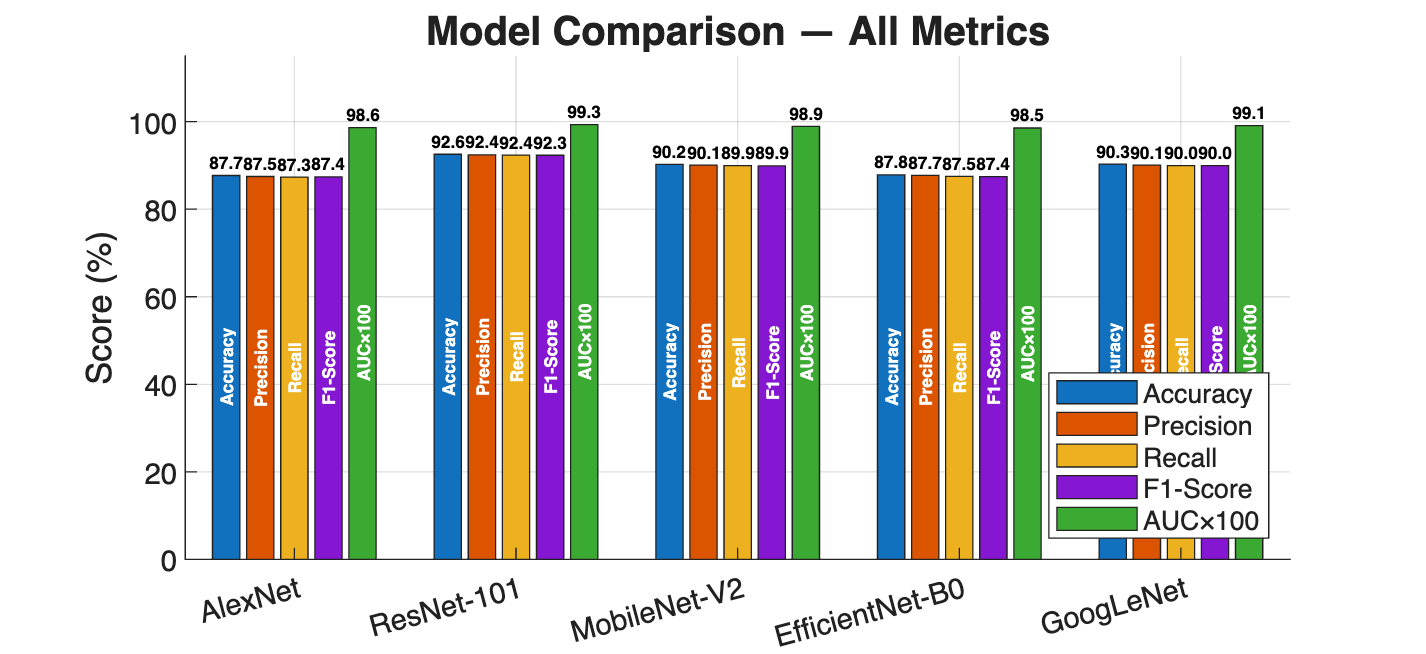

In [35]:
%% ── FIGURE 1: COMBINED METRICS COMPARISON ───────────────
% X-axis groups = Models, Bars within group = Metrics

palette      = lines(5);   % 5 colours for 5 metrics
metricLabels = {'Accuracy','Precision','Recall','F1-Score','AUC×100'};
modelNames   = cleanNames;

% Transpose so rows=models, cols=metrics → bar groups by model
% metricMatrix is already (numValid x 5) so use directly
figure('Name','Combined Metrics Comparison','NumberTitle','off', ...
       'Position',[100 100 1200 550]);

b = bar(metricMatrix, 'grouped');   % each group = one model, each bar = one metric

% Colour each bar series by METRIC
for i = 1:numel(b)
    b(i).FaceColor = palette(i,:);
end

% X-axis labels = model names
set(gca, ...
    'XTick',       1:numValid, ...
    'XTickLabel',  modelNames, ...
    'XTickLabelRotation', 15, ...
    'FontSize',    11);

ylabel('Score (%)', 'FontSize', 13);
title('Model Comparison — All Metrics', 'FontSize', 15, 'FontWeight', 'bold');
legend(metricLabels, 'Location', 'southeast', 'FontSize', 10);
ylim([0 115]);
grid on; box off;

% ── ANNOTATIONS ──────────────────────────────────────────
% i = metric bar series (1..5)
% g = model group/position (1..numValid)
for i = 1:numel(b)              % loop metrics
    for g = 1:numValid          % loop models
        xPos = b(i).XEndPoints(g);
        yVal = b(i).YData(g);

        % Numeric value on top
        text(xPos, yVal + 0.8, ...
             sprintf('%.1f', yVal), ...
             'HorizontalAlignment', 'center', ...
             'VerticalAlignment',   'bottom', ...
             'FontSize',            6.5, ...
             'FontWeight',          'bold', ...
             'Color',               'k');

        % Metric name vertically inside bar
        text(xPos, yVal / 2, ...
             metricLabels{i}, ...      % ← metric name inside each bar
             'HorizontalAlignment', 'center', ...
             'VerticalAlignment',   'middle', ...
             'FontSize',            6.5, ...
             'FontWeight',          'bold', ...
             'Color',               'w', ...
             'Rotation',            90);
    end
end



**FIGURE 2 — ACCURACY COMPARISON (standalone, prominent)**



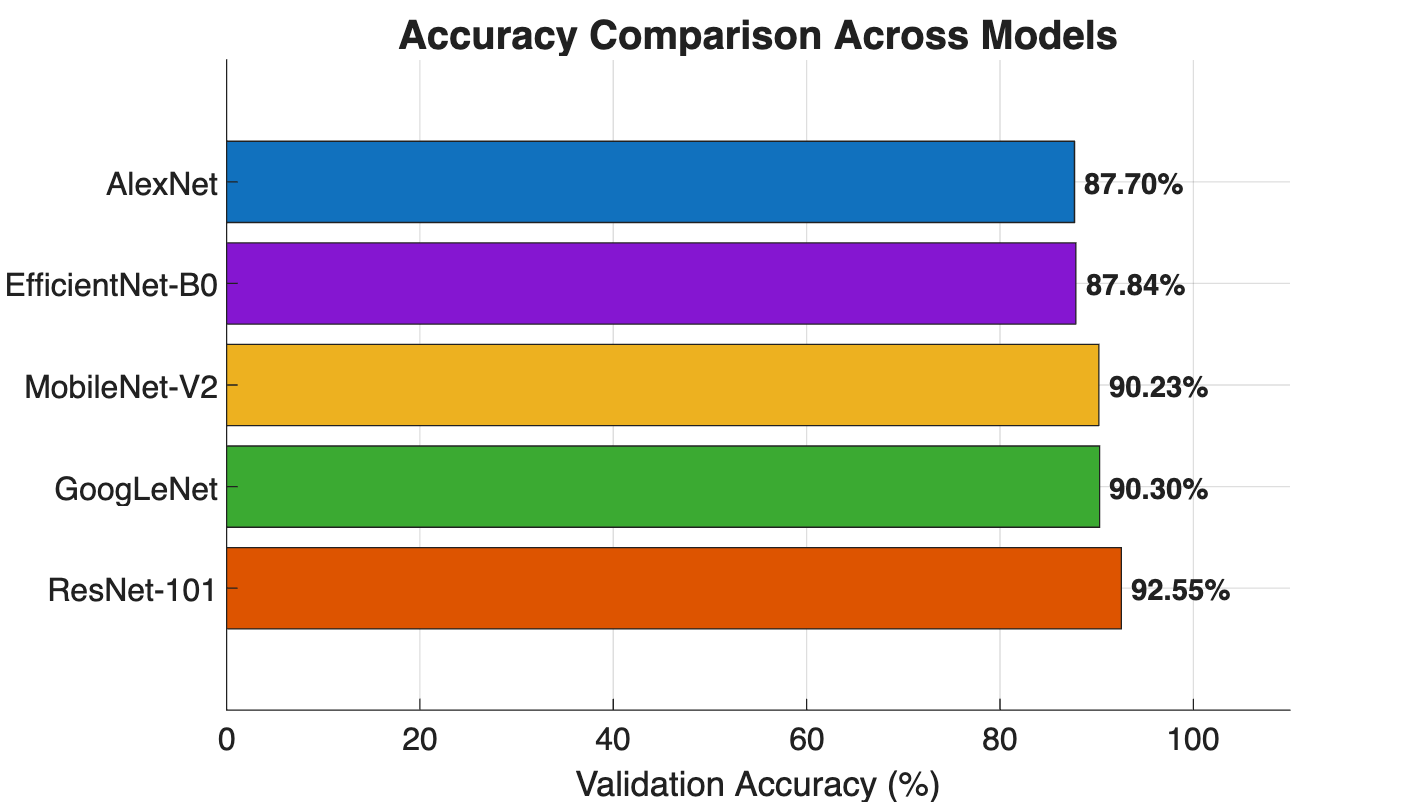

In [36]:
accuracies = [allMetrics.accuracy];
[sortedAcc, sortIdx] = sort(accuracies, 'descend');
sortedNames = modelNames(sortIdx);

figure('Name','Accuracy Comparison','NumberTitle','off', ...
       'Position',[100 100 800 450]);
hb = barh(sortedAcc, 'FaceColor','flat');
for i = 1:numValid
    hb.CData(i,:) = palette(sortIdx(i),:);
end
set(gca, 'YTickLabel', sortedNames, 'FontSize', 12);
xlabel('Validation Accuracy (%)', 'FontSize', 13);
title('Accuracy Comparison Across Models', 'FontSize', 15, 'FontWeight','bold');
xlim([0 110]);
grid on; box off;
for i = 1:numValid
    text(sortedAcc(i)+1, i, sprintf('%.2f%%', sortedAcc(i)), ...
         'VerticalAlignment','middle', 'FontSize', 11, 'FontWeight','bold');
end


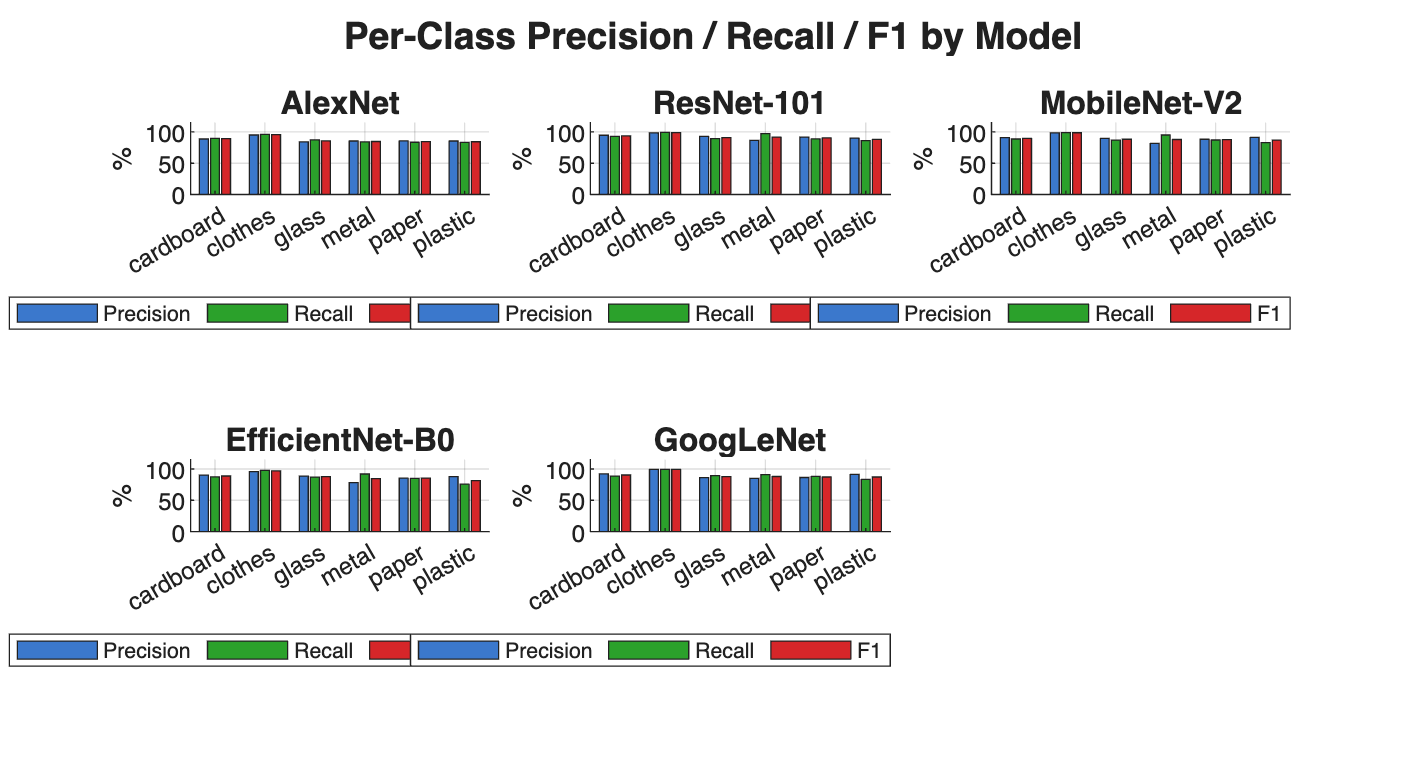

In [37]:

% FIGURE 3 — PER-CLASS METRICS (one subplot per model)
% Each subplot: grouped bar with Precision / Recall / F1 per class

nCols = min(numValid, 3);
nRows = ceil(numValid / nCols);
figure('Name','Per-Class Metrics per Model','NumberTitle','off', ...
       'Position',[100 100 420*nCols 340*nRows]);

for m = 1:numValid
    subplot(nRows, nCols, m);
    perClass = [ allMetrics(m).perClassP, ...
                 allMetrics(m).perClassR, ...
                 allMetrics(m).perClassF1 ];
    b2 = bar(perClass, 'grouped');
    b2(1).FaceColor = [0.23 0.47 0.80];
    b2(2).FaceColor = [0.17 0.63 0.17];
    b2(3).FaceColor = [0.84 0.15 0.16];
    set(gca, 'XTickLabel', classNames, 'XTickLabelRotation', 30, 'FontSize', 9);
    ylabel('%', 'FontSize', 10);
    title(allMetrics(m).name, 'FontSize', 12, 'FontWeight', 'bold');
    legend({'Precision','Recall','F1'}, 'Location','southoutside', ...
           'Orientation','horizontal', 'FontSize', 8);
    ylim([0 115]); grid on; box off;
end
sgtitle('Per-Class Precision / Recall / F1 by Model', 'FontSize', 14, 'FontWeight','bold');



**FIGURE 4 — AUC\-ROC CURVES (one subplot per model)**



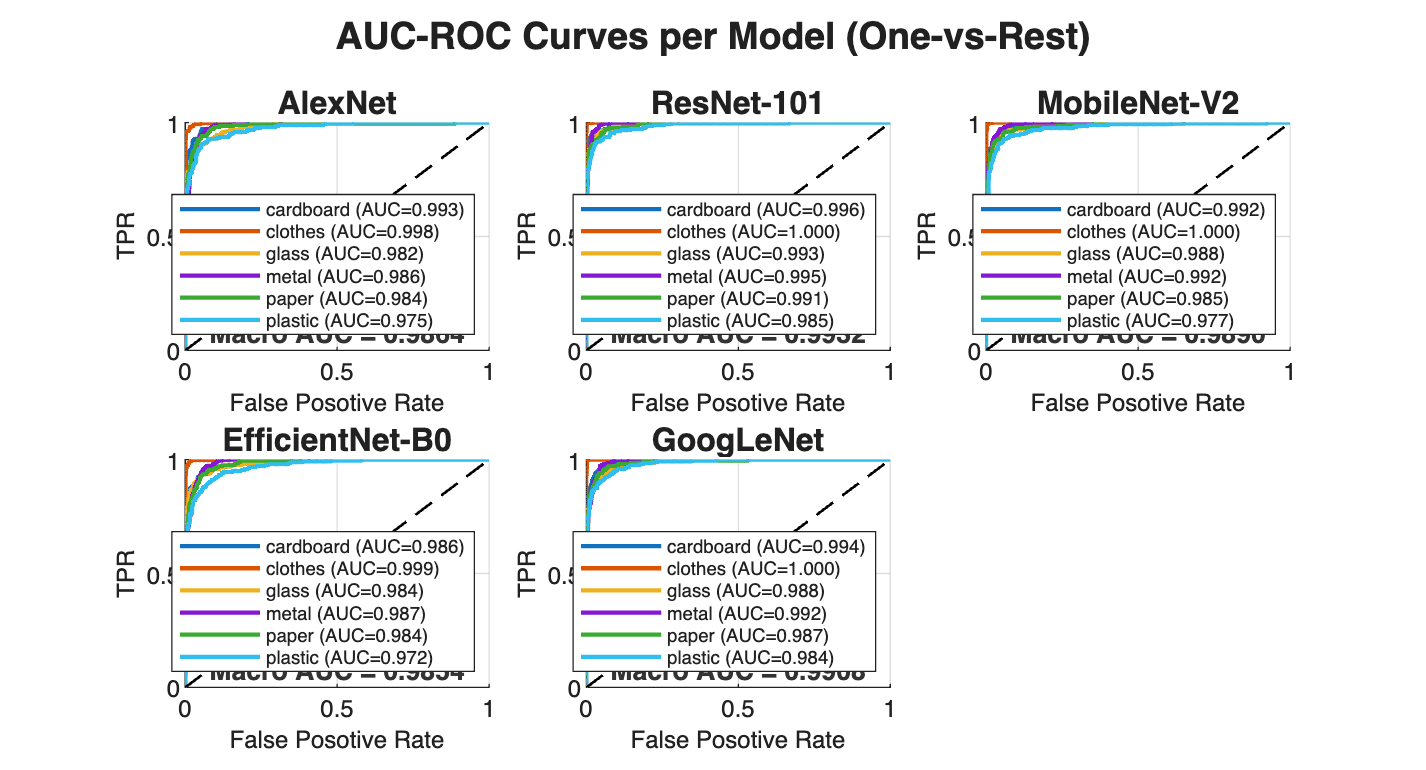

In [38]:
figure('Name','AUC-ROC Curves','NumberTitle','off', ...
       'Position',[100 100 420*nCols 340*nRows]);
classColors = lines(numClasses);

for m = 1:numValid
    subplot(nRows, nCols, m);
    hold on;
    scores_m = allScores{m};

    for c = 1:numClasses
        binaryTrue = double(strcmp(cellstr(YTrue), classNames{c}));
        [Xroc, Yroc, ~, aucVal] = perfcurve(binaryTrue, scores_m(:,c), 1);
        plot(Xroc, Yroc, 'Color', classColors(c,:), 'LineWidth', 1.6, ...
             'DisplayName', sprintf('%s (AUC=%.3f)', classNames{c}, aucVal));
    end
    plot([0 1],[0 1],'k--','LineWidth',1,'HandleVisibility','off');
    xlabel('False Posotive Rate','FontSize',9); ylabel('TPR','FontSize',9);
    title(modelNames(m),'FontSize',12,'FontWeight','bold');
    legend('Location','southeast','FontSize',7);
    xlim([0 1]); ylim([0 1]); grid on; box off;
    text(0.5, 0.08, sprintf('Macro AUC = %.4f', allMetrics(m).auc), ...
         'HorizontalAlignment','center','FontSize',10,'FontWeight','bold', ...
         'Color',[0.2 0.2 0.2]);
end
sgtitle('AUC-ROC Curves per Model (One-vs-Rest)', 'FontSize', 14, 'FontWeight','bold');



**FIGURE 5 — CONFUSION MATRIX (one per model)**



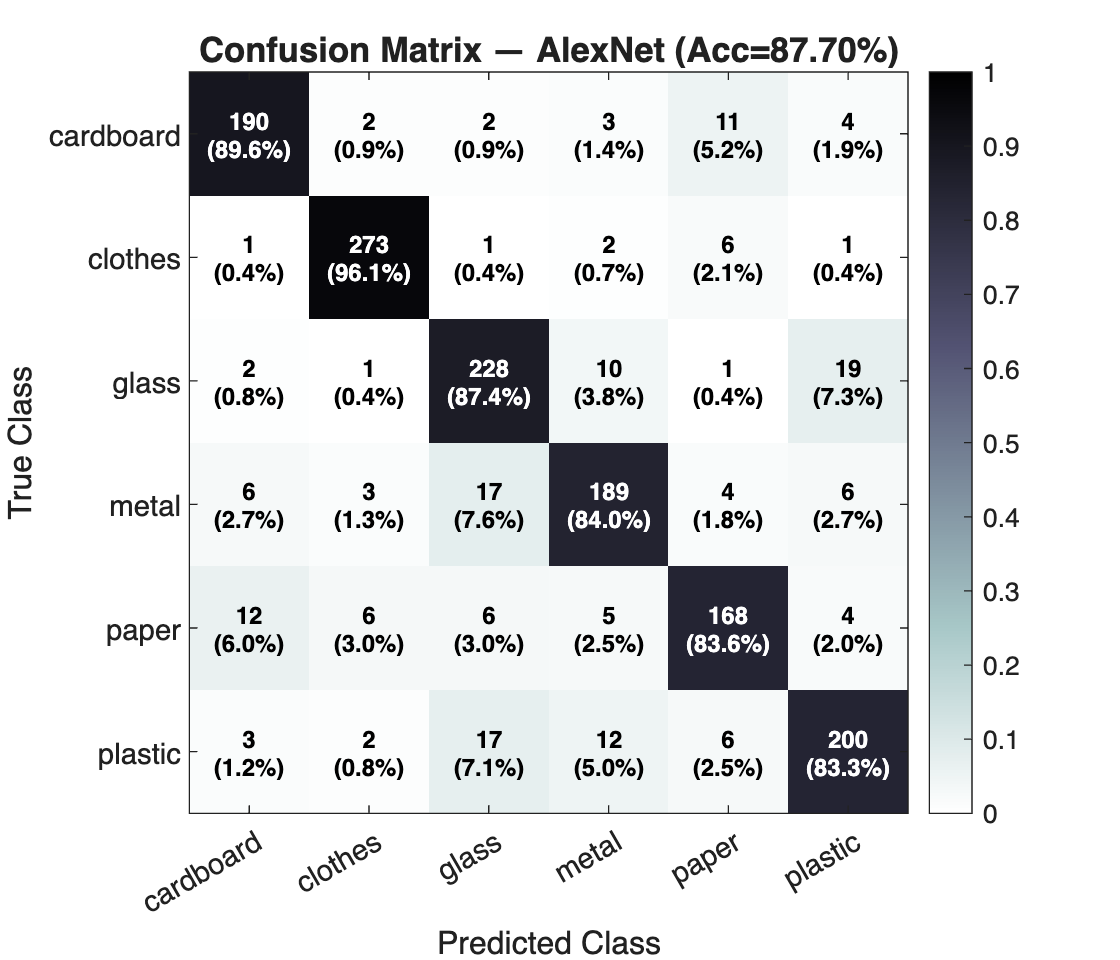


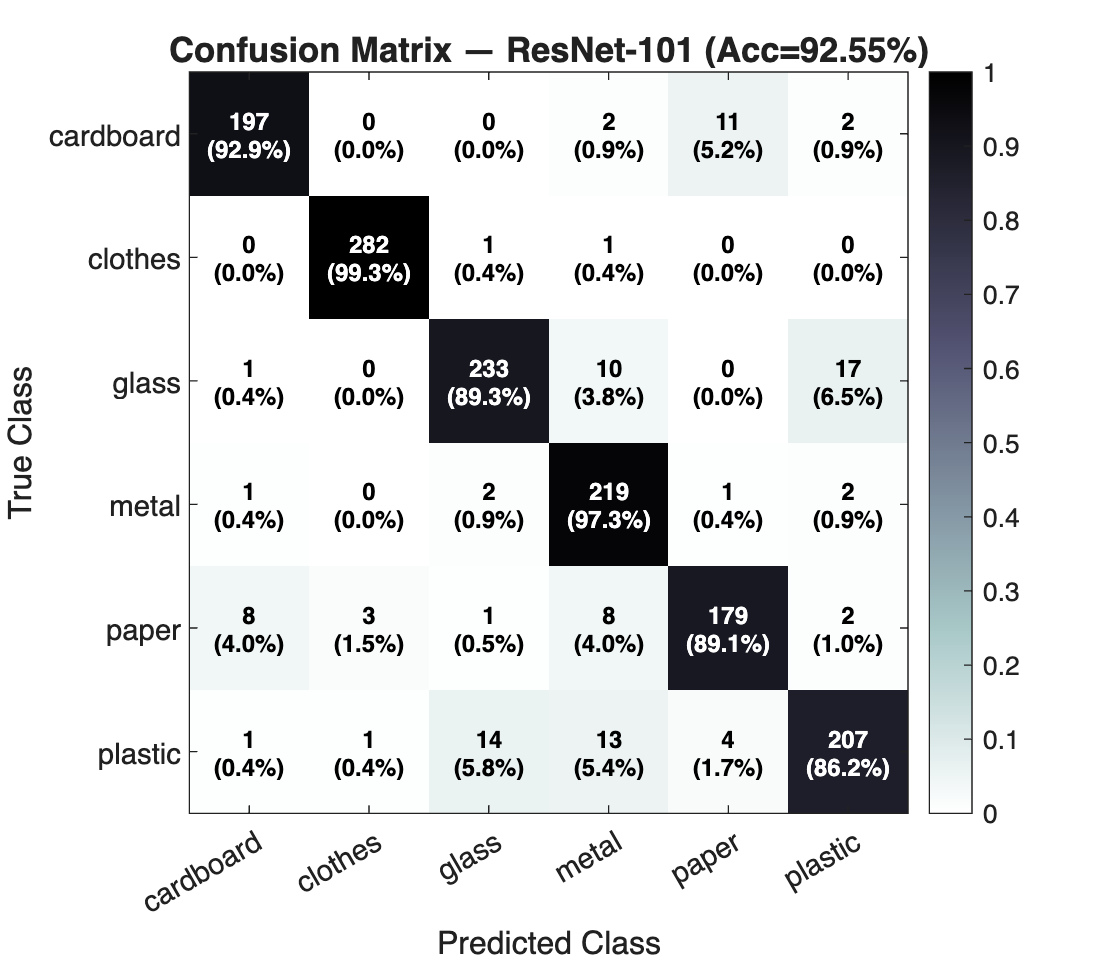

In [39]:
for m = 1:numValid
    figure('Name', sprintf('Confusion Matrix — %s', allMetrics(m).name), ...
           'NumberTitle','off','Position',[150+m*30 150 560 480]);

    C_norm = allMetrics(m).confMat ./ sum(allMetrics(m).confMat, 2);
    imagesc(C_norm);
    colormap(flipud(bone));
    colorbar;
    clim([0 1]);

    % Annotate cells
    for r = 1:numClasses
        for col = 1:numClasses
            raw = allMetrics(m).confMat(r,col);
            pct = C_norm(r,col);
            clr = 'k';
            if pct > 0.55, clr = 'w'; end
            text(col, r, sprintf('%d\n(%.1f%%)', raw, pct*100), ...
                 'HorizontalAlignment','center','VerticalAlignment','middle', ...
                 'FontSize', 9, 'FontWeight','bold', 'Color', clr);
        end
    end

    set(gca, 'XTick',1:numClasses,'XTickLabel',classNames,'XTickLabelRotation',30, ...
             'YTick',1:numClasses,'YTickLabel',classNames,'FontSize',11);
    xlabel('Predicted Class','FontSize',12);
    ylabel('True Class','FontSize',12);
    title(sprintf('Confusion Matrix — %s (Acc=%.2f%%)', ...
          allMetrics(m).name, allMetrics(m).accuracy), ...
          'FontSize',13,'FontWeight','bold');
end

<center>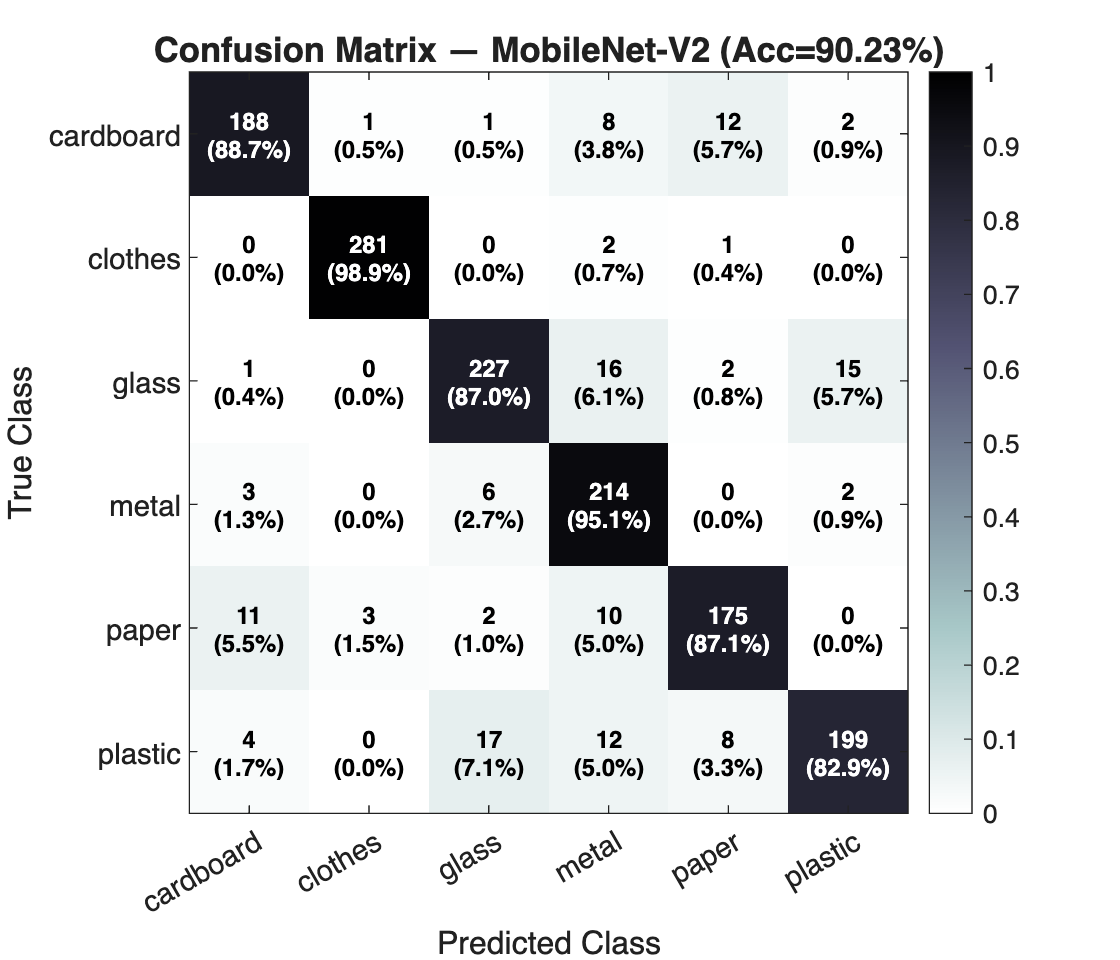</center>


<center>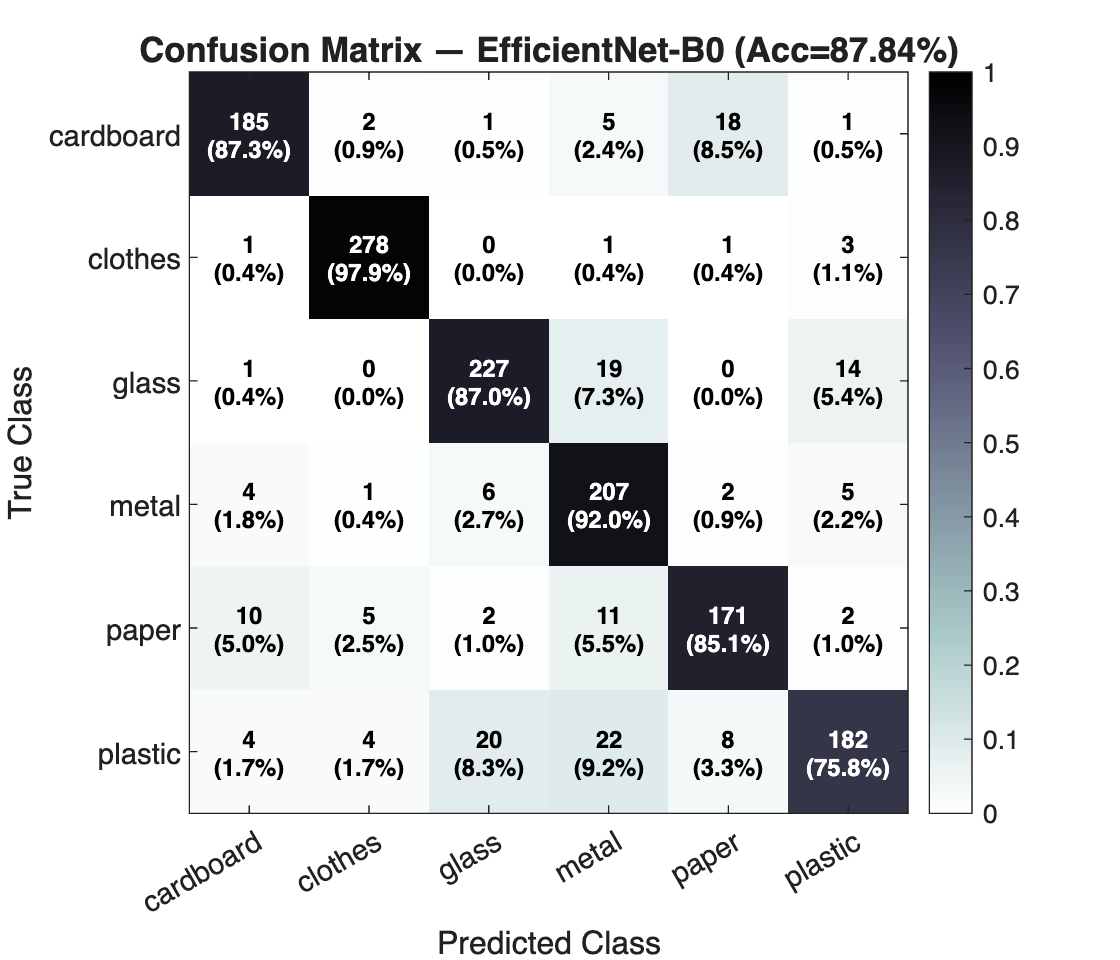</center>


<center>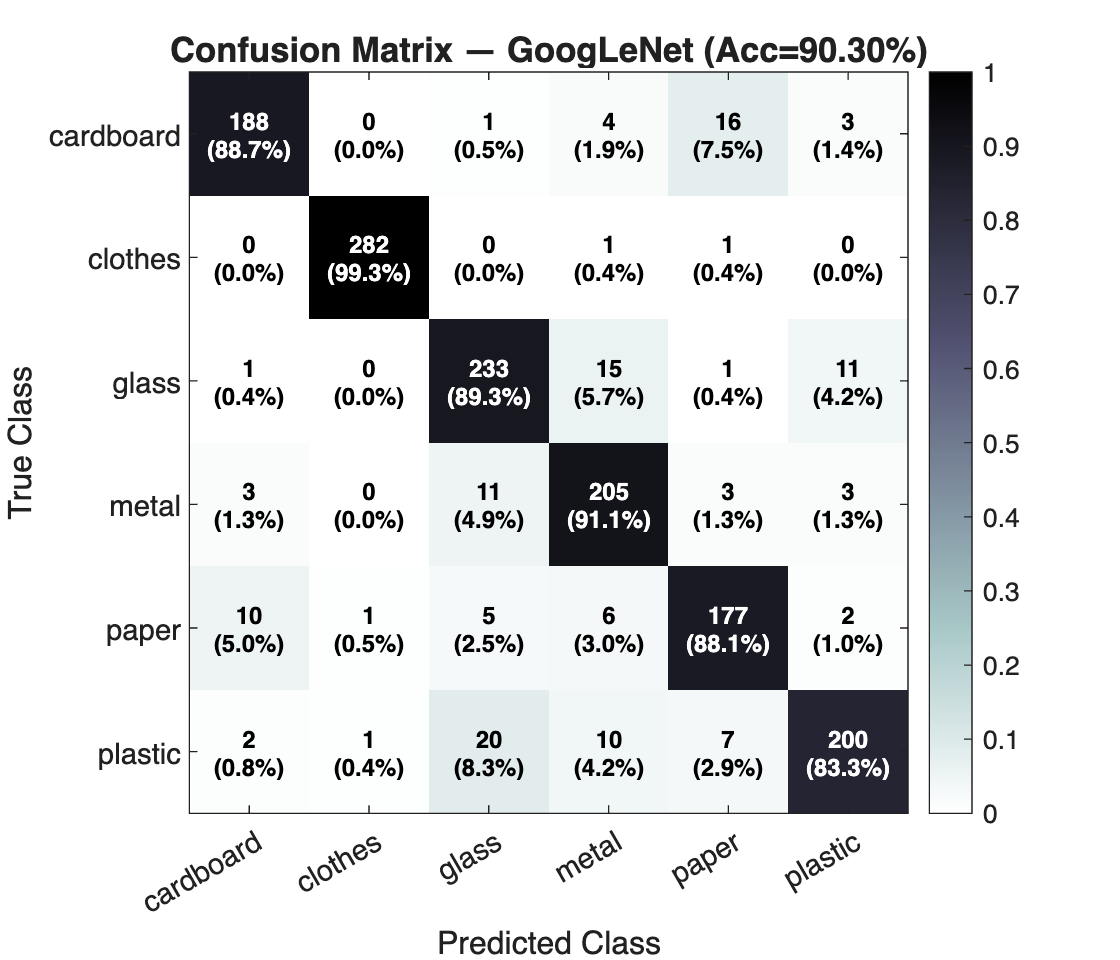</center>




**EXPERIMENT SUMMARY**


In [41]:
fprintf('%-18s %8s %10s %8s %8s %8s\n', ...
    'Model','Acc(%)','Prec(%)','Rec(%)','F1(%)','AUC');

Model                Acc(%)    Prec(%)   Rec(%)    F1(%)      AUC

In [42]:

fprintf('%s\n', repmat('-',1,65));

-----------------------------------------------------------------

In [43]:
for m = 1:numValid
    fprintf('%-18s %8.2f %10.2f %8.2f %8.2f %8.4f\n', ...
        allMetrics(m).name, ...
        allMetrics(m).accuracy, ...
        allMetrics(m).precision, ...
        allMetrics(m).recall, ...
        allMetrics(m).f1, ...
        allMetrics(m).auc);
end

AlexNet               87.70      87.46    87.34    87.39   0.9864
ResNet-101            92.55      92.42    92.36    92.32   0.9932
MobileNet-V2          90.23      90.08    89.95    89.89   0.9890
EfficientNet-B0       87.84      87.72    87.51    87.44   0.9854
GoogLeNet             90.30      90.08    89.96    89.96   0.9908

In [44]:
fprintf('%s\n', repmat('=',1,65));

In [45]:

% Find best model
[~, bestIdx] = max([allMetrics.accuracy]);
fprintf('\n★  Best model by accuracy: %s (%.2f%%)\n\n', ...
    allMetrics(bestIdx).name, allMetrics(bestIdx).accuracy);

★  Best model by accuracy: ResNet-101 (92.55%)



**REEVALUATING BEST MODEL TO PERFROMANCE ON IMDSTEST OUTPUT**


In [46]:
%% ── RESNET-101 RETRAIN + TEST EVALUATION ─────────────────
% Self-contained block — saves trainedNet, evaluates on imdsTest

modelName      = 'ResNet-101';
inputSz        = [224 224 3];
checkpointDir  = fullfile('GarbageDataset', 'checkpoints');
checkpointFile = fullfile(checkpointDir, 'ResNet-101_results.mat');

if ~exist(checkpointDir,'dir'), mkdir(checkpointDir); end

%% ── AUGMENTATION & DATASTORES ────────────────────────────
augmenter = imageDataAugmenter( ...
    'RandXReflection',  true, ...
    'RandXTranslation', [-30 30], ...
    'RandYTranslation', [-30 30], ...
    'RandRotation',     [-15 15]);

imdsTrain.ReadFcn      = @(f) imread(f);
imdsValidation.ReadFcn = @(f) imread(f);

augimdsTrain = augmentedImageDatastore(inputSz(1:2), imdsTrain, ...
                   'DataAugmentation',   augmenter, ...
                   'ColorPreprocessing', 'gray2rgb');
augimdsValidation = augmentedImageDatastore(inputSz(1:2), imdsValidation, ...
                        'ColorPreprocessing', 'gray2rgb');

%% ── BUILD NETWORK ────────────────────────────────────────
net    = resnet101;
lgraph = layerGraph(net);
layers = lgraph.Layers;
numL   = numel(layers);

outputLayerName  = layers(numL).Name;
softmaxLayerName = layers(numL-1).Name;
fcLayerName      = layers(numL-2).Name;

fprintf('Replacing: %s | %s | %s\n', ...
    fcLayerName, softmaxLayerName, outputLayerName);

Replacing: fc1000 | prob | ClassificationLayer_predictions

In [47]:

newFC      = fullyConnectedLayer(numClasses, ...
                 'WeightLearnRateFactor', 20, ...
                 'BiasLearnRateFactor',   20, ...
                 'Name', fcLayerName);
newSoftmax = softmaxLayer('Name', softmaxLayerName);
newOutput  = classificationLayer('Name', outputLayerName);

lgraph = replaceLayer(lgraph, fcLayerName,      newFC);
lgraph = replaceLayer(lgraph, softmaxLayerName, newSoftmax);
lgraph = replaceLayer(lgraph, outputLayerName,  newOutput);

%% ── TRAINING OPTIONS ─────────────────────────────────────
options = trainingOptions('sgdm', ...
    'MiniBatchSize',       32, ...
    'MaxEpochs',           8, ...
    'InitialLearnRate',    1e-4, ...
    'LearnRateSchedule',   'piecewise', ...
    'LearnRateDropFactor', 0.5, ...
    'LearnRateDropPeriod', 4, ...
    'L2Regularization',    1e-4, ...
    'Momentum',            0.9, ...
    'Shuffle',             'every-epoch', ...
    'ValidationData',      augimdsValidation, ...
    'ValidationFrequency', 10, ...
    'Verbose',             true, ...
    'Plots',               'training-progress');
%% ── TRAIN ────────────────────────────────────────────────
fprintf('\n===========================================\n');

In [48]:
fprintf('  Training: %s\n', modelName);

  Training: ResNet-101

In [49]:
fprintf('===========================================\n');

Training on single CPU.
Initializing input data normalization.
|======================================================================================================================|
|  Epoch  |  Iteration  |  Time Elapsed  |  Mini-batch  |  Validation  |  Mini-batch  |  Validation  |  Base Learning  |
|         |             |   (hh:mm:ss)   |   Accuracy   |   Accuracy   |     Loss     |     Loss     |      Rate       |
|======================================================================================================================|
|       1 |           1 |       00:01:29 |       15.62% |       12.93% |       2.4253 |       2.2932 |      1.0000e-04 |
|       1 |          10 |       00:04:15 |       34.38% |       39.63% |       1.6385 |       1.5787 |      1.0000e-04 |
|       1 |          20 |       00:07:38 |       62.50% |       66.97% |       1.0291 |       0.9301 |      1.0000e-04 |
|       1 |          30 |       00:10:50 |       65.62% |       75.76% |       0.8103 |   


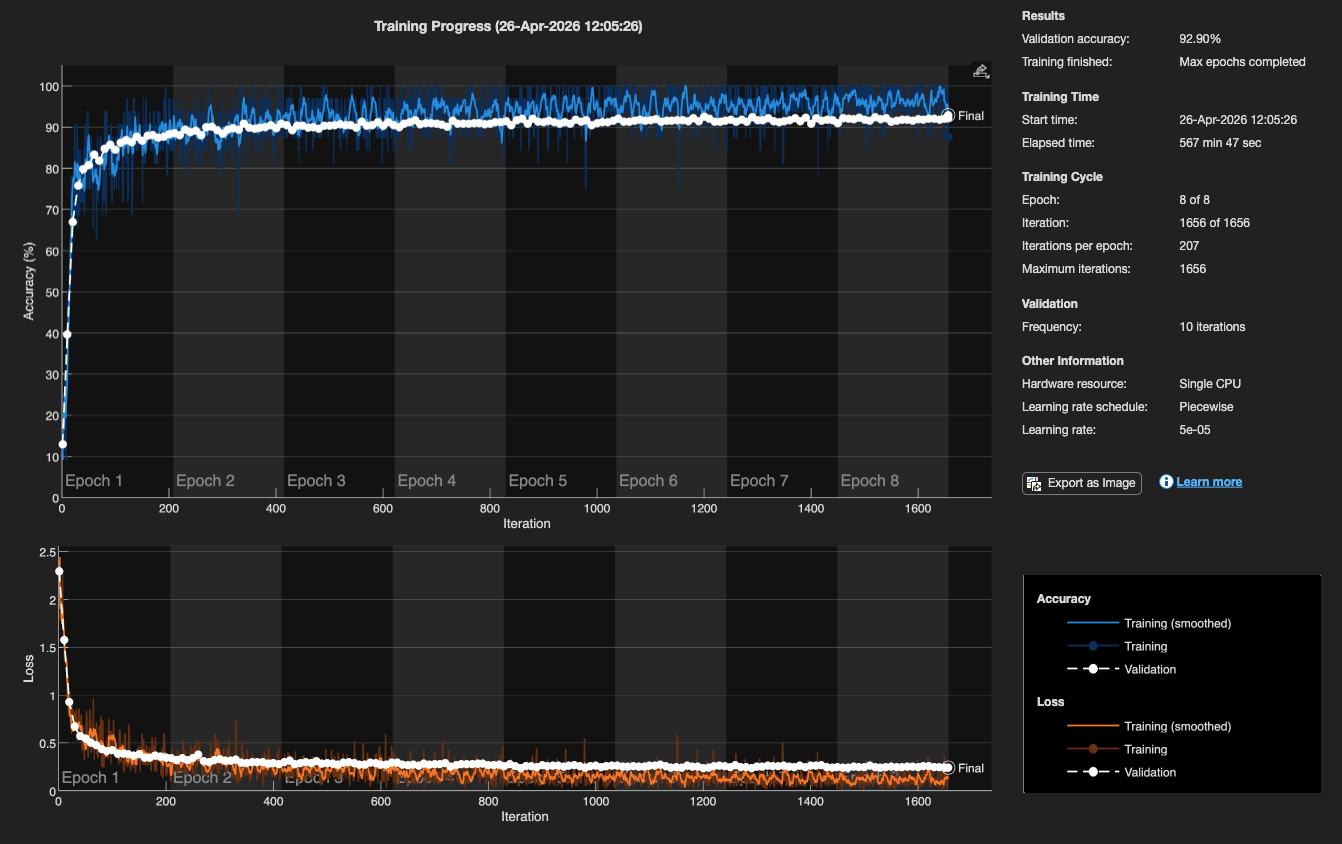

In [50]:

trainedNet_ResNet101 = trainNetwork(augimdsTrain, lgraph, options);

In [51]:

%% ── VALIDATION METRICS ───────────────────────────────────
[YPred, scores] = classify(trainedNet_ResNet101, augimdsValidation);
YTrue           = imdsValidation.Labels;

C = confusionmat(YTrue, YPred);
precision = zeros(numClasses,1);
recall    = zeros(numClasses,1);
f1        = zeros(numClasses,1);
for c = 1:numClasses
    TP = C(c,c); FP = sum(C(:,c))-TP; FN = sum(C(c,:))-TP;
    precision(c) = TP/max(TP+FP,1);
    recall(c)    = TP/max(TP+FN,1);
    f1(c) = 2*precision(c)*recall(c)/max(precision(c)+recall(c),eps);
end
accuracy = mean(YPred == YTrue);
auc = zeros(numClasses,1);
for c = 1:numClasses
    bin = double(strcmp(cellstr(YTrue), classNames{c}));
    [~,~,~,auc(c)] = perfcurve(bin, scores(:,c), 1);
end

metrics.name        = modelName;
metrics.accuracy    = accuracy * 100;
metrics.precision   = mean(precision) * 100;
metrics.recall      = mean(recall)    * 100;
metrics.f1          = mean(f1)        * 100;
metrics.auc         = mean(auc);
metrics.perClassP   = precision * 100;
metrics.perClassR   = recall    * 100;
metrics.perClassF1  = f1        * 100;
metrics.perClassAUC = auc;
metrics.confMat     = C;

fprintf('\n[%s] Val — Acc=%.2f%%  Prec=%.2f%%  Rec=%.2f%%  F1=%.2f%%  AUC=%.4f\n', ...
    modelName, metrics.accuracy, metrics.precision, ...
    metrics.recall, metrics.f1, metrics.auc);

[ResNet-101] Val — Acc=92.90%  Prec=92.80%  Rec=92.62%  F1=92.63%  AUC=0.9934

In [52]:

%% ── SAVE CHECKPOINT WITH trainedNet ─────────────────────
trainedNet = trainedNet_ResNet101;   % standard name for compatibility
save(checkpointFile, 'metrics', 'YPred', 'scores', 'YTrue', 'trainedNet');
fprintf('[%s] Checkpoint saved with trainedNet.\n', modelName);

[ResNet-101] Checkpoint saved with trainedNet.

In [53]:

% Verify trainedNet is in checkpoint
v = load(checkpointFile);
fprintf('Verified trainedNet in checkpoint: %s\n', ...
    mat2str(isfield(v,'trainedNet')));

Verified trainedNet in checkpoint: true

In [54]:

%% ── TEST SET EVALUATION ──────────────────────────────────
fprintf('\n===========================================\n');

In [55]:
fprintf('  Test Evaluation: %s\n', modelName);

  Test Evaluation: ResNet-101

In [56]:
fprintf('===========================================\n');

In [57]:

imdsTest.ReadFcn = @(f) imread(f);
augimdsTest = augmentedImageDatastore(inputSz(1:2), imdsTest, ...
                  'ColorPreprocessing', 'gray2rgb');

[YTestPred, testScores] = classify(trainedNet_ResNet101, augimdsTest);
YTestTrue = imdsTest.Labels;
tAcc      = mean(YTestPred == YTestTrue) * 100;

% Per-class test metrics
C2 = confusionmat(YTestTrue, YTestPred);
p2 = zeros(numClasses,1);
r2 = zeros(numClasses,1);
f2 = zeros(numClasses,1);
for c = 1:numClasses
    TP = C2(c,c); FP = sum(C2(:,c))-TP; FN = sum(C2(c,:))-TP;
    p2(c) = TP/max(TP+FP,1);
    r2(c) = TP/max(TP+FN,1);
    f2(c) = 2*p2(c)*r2(c)/max(p2(c)+r2(c),eps);
end
auc2 = zeros(numClasses,1);
for c = 1:numClasses
    bin = double(strcmp(cellstr(YTestTrue), classNames{c}));
    [~,~,~,auc2(c)] = perfcurve(bin, testScores(:,c), 1);
end

testMetrics.accuracy    = tAcc;
testMetrics.precision   = mean(p2) * 100;
testMetrics.recall      = mean(r2) * 100;
testMetrics.f1          = mean(f2) * 100;
testMetrics.auc         = mean(auc2);
testMetrics.perClassP   = p2 * 100;
testMetrics.perClassR   = r2 * 100;
testMetrics.perClassF1  = f2 * 100;
testMetrics.perClassAUC = auc2;
testMetrics.confMat     = C2;

% Append testMetrics to checkpoint
save(checkpointFile, 'metrics', 'YPred', 'scores', 'YTrue', ...
     'trainedNet', 'testMetrics');
fprintf('[%s] testMetrics saved to checkpoint.\n', modelName);

[ResNet-101] testMetrics saved to checkpoint.

In [58]:

%% ── FINAL COMPARISON SUMMARY ─────────────────────────────
vAcc = metrics.accuracy;
diff = tAcc - vAcc;
clr_flag = '';
if diff < -3, clr_flag = '  ← possible overfit'; end

fprintf('\n========== ResNet-101 FINAL RESULTS ==========\n');

========== ResNet-101 FINAL RESULTS ==========

In [59]:
fprintf('%-20s %10s %10s %10s\n','Metric','Val','Test','Difference');

Metric                      Val       Test Difference

In [60]:
fprintf('%s\n', repmat('-',1,52));

----------------------------------------------------

In [61]:
fprintf('%-20s %10.2f%% %10.2f%% %+10.2f%%%s\n', ...
    'Accuracy', vAcc, tAcc, diff, clr_flag);

Accuracy                  92.90%      92.96%      +0.06%

In [62]:
fprintf('%-20s %10.2f%% %10.2f%%\n', ...
    'Precision', metrics.precision, testMetrics.precision);

Precision                 92.80%      92.68%

In [63]:
fprintf('%-20s %10.2f%% %10.2f%%\n', ...
    'Recall',    metrics.recall,    testMetrics.recall);

Recall                    92.62%      92.50%

In [64]:
fprintf('%-20s %10.2f%% %10.2f%%\n', ...
    'F1-Score',  metrics.f1,        testMetrics.f1);

F1-Score                  92.63%      92.54%

In [65]:
fprintf('%-20s %10.4f  %10.4f\n', ...
    'AUC',       metrics.auc,       testMetrics.auc);

AUC                      0.9934      0.9942

In [66]:
fprintf('%s\n', repmat('=',1,52));


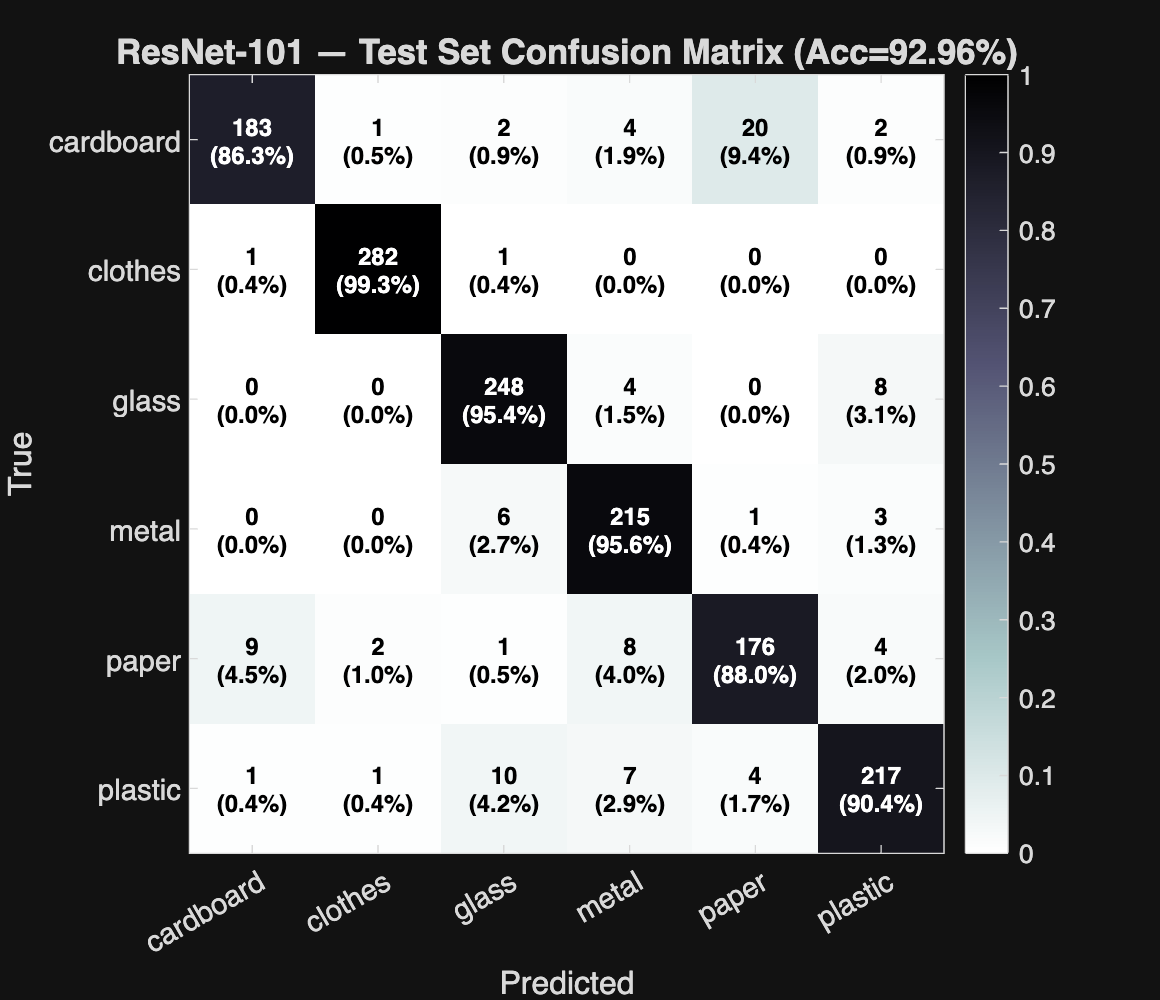

In [67]:

%% ── CONFUSION MATRIX — TEST SET ─────────────────────────
figure('Name','ResNet-101 Test Confusion Matrix', ...
       'NumberTitle','off','Position',[100 100 580 500]);
C2_norm = C2 ./ sum(C2,2);
imagesc(C2_norm); colormap(flipud(bone)); colorbar; clim([0 1]);
for r = 1:numClasses
    for col = 1:numClasses
        clr = 'k'; if C2_norm(r,col) > 0.55, clr='w'; end
        text(col, r, sprintf('%d\n(%.1f%%)', C2(r,col), C2_norm(r,col)*100), ...
             'HorizontalAlignment','center','FontSize',9, ...
             'FontWeight','bold','Color',clr);
    end
end
set(gca,'XTick',1:numClasses,'XTickLabel',classNames,'XTickLabelRotation',30, ...
        'YTick',1:numClasses,'YTickLabel',classNames,'FontSize',11);
xlabel('Predicted','FontSize',12); ylabel('True','FontSize',12);
title(sprintf('ResNet-101 — Test Set Confusion Matrix (Acc=%.2f%%)', tAcc), ...
      'FontSize',13,'FontWeight','bold');